<h1><center> Chapitre III :</center></h1>
<h1><center> Classification d'Images<br><i>- Doodles Quick, Draw! -</i></center></h1>
<hr>

## Motivation et Objectifs

Après avoir exploré les algorithmes de classification supervisée (SVM, Régression Logistique, Naive Bayes, Decision Tree et KNN) dans le cadre de nos projets sur l'analyse de sentiments et la classification d'iris, nous abordons désormais un aspect qualitativement différent en machine learning : la **vision par ordinateur**.

En effet, jusqu'ici, nos données n'étaient constituées que de features numériques bien définies, faciles à visualiser et à interpréter. Les images quant à elles, présentent une certaine **structure spatiale**, une **dimensionnalité très élevée**, et de fortes **corrélations locales** entre pixels voisins. Ces propriétés rendent les modèles que l'on connaît structurellement inadaptés, et c'est précisément ce que l'on cherchera à démontrer dans ce notebook.

La question centrale de ce notebook à laquelle nous nous attacherons à répondre sera donc :
> **Pourquoi les modèles linéaires et les perceptrons multicouches entièrement connectés sont-ils insuffisants pour la vision par ordinateur, et comment les réseaux convolutionnels corrigent-ils ces limitations ?**

Pour y répondre, on commencera par appliquer une **régression logistique multiclasse** sur des images vectorisées, pour identifier précisément les limites d'une approche linéaire. Ensuite, on développera la théorie derrière les réseaux de neuronnes, puis on construira un **perceptron multicouche (MLP)** et un **réseaux convolutionnels (CNN)** *from scratch*, en dérivant toutes les équations de rétro-propagation à la main. Enfin, on approfondira les aspects théoriques des CNN afin d'introduire la dernière partie de cette analyse de méthodes du machine learning.

### Problématique

Formellement, notre dataset supervisé s'écrit $\mathcal{D} = \{(x_i, y_i)\}_{i=1}^{n}$, où $x_i \in \mathbb{R}^{h \times w}$ est une image de hauteur $h$ et largeur $w$, et $y_i \in \{1, \dots, K\}$ désigne l'étiquette de classe parmi $K$ catégories de doodles. 

Après une éventuelle vectorisation, on obtient : $\tilde{x}_i \in \mathbb{R}^{d}$ avec $d = h \times w$. 

On cherche alors une fonction paramétrée $f_\theta$ minimisant le **risque empirique** :

$$\text{nb-couche}(\theta) = \frac{1}{n} \sum_{i=1}^{n} \ell\big(f_\theta(x_i),\, y_i\big)$$

Dans un cadre de classification multiclasse probabiliste, $\ell$ sera la **cross-entropy** : $\ell = - \sum_{k=1}^{K} \mathbf{1}_{y=k} \log p_k$, où $p_k$ est la probabilité prédite pour la classe $k$.

#### Importation des bibliothèques

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import pandas as pd
import seaborn as sns
import utils.show_utils as show_info # cf. /utils

# Choix des palettes
#plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
BACKGROUND_CMAP = "coolwarm"

## I. Le Dataset Quick, Draw!

Le dataset **Quick, Draw!** a été constitué par Google dans le cadre d'un jeu en ligne où des millions d'utilisateurs devaient dessiner des objets en moins de vingt secondes. Il contient aujourd'hui plus de *50 millions* de dessins répartis en *345 catégories* (allant des animaux aux instruments de musique en passant par des véhicules ou des objets du quotidien). Chaque dessin y a déjà été converti en un vecteur de dimension $d = 784$ représentant une image en niveaux de gris de $28 \times 28$ pixels.

Concrètement, nous avons décidé de travailler sur ce dataset afin de mettre en évidence les limites des approches plus naïves comme la régression linéaire. En effet, les dessins y sont plutôt bruités et peuvent être stylisés complètement différemment selon les utilisateurs. De plus, les images de taille $28 \times 28$, permettent à notre modèle de rester compatibles avec un entraînement sur CPU standard, ce qui permet à n'importe quelle machine d'entrainer et de tester ce modèle.

Pour garder les temps d'entraînement raisonnables, nous allons restreindre volontairement notre étude à 4 classes (chat, oiseau, poisson, et cheval), mais ce choix ne change en rien la généralité des conclusions puisque les limites mises en évidence ne sont pas spécifiques au nombre de classes.

In [29]:
animaux = ['cat', 'bird', 'fish', 'horse']
nb_classes = len(animaux)


### I.1. Chargement et visualisation du dataset

#### I.1.1. Téléchargement du dataset au format NumPy

In [30]:
import urllib.request
import os

base_url = "https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/"
path = os.path.join("data", "animaux_dataset")

if not os.path.exists(path):
    os.makedirs(path)

for animal in animaux:
    file_name = f"{animal}.npy"
    print(f"Téléchargement de {file_name}...")
    try:
        urllib.request.urlretrieve(base_url + file_name, os.path.join(path, file_name))
    except:
        print(f"Erreur pour {animal}")

print("Terminé !")

Téléchargement de cat.npy...
Téléchargement de bird.npy...
Téléchargement de fish.npy...
Téléchargement de horse.npy...
Terminé !


#### I.1.2. Vectorisation des fichiers NumPy

In [31]:
class_files = {}

for i in range(len(animaux)):
    path = os.path.join("data", "animaux_dataset", f"{animaux[i]}.npy")
    if os.path.exists(path):
        class_files[i] = path
    else:
        print(f"Fichier manquant : {path}")

X_list = []
y_list = []

max_items_per_class = 6000 

for label, path in class_files.items():
    data = np.load(path)              
    data = data[:max_items_per_class] # (6000, 784)
    X_list.append(data)
    y_list.append(np.full(len(data), label))

X = np.vstack(X_list)   # shape (classes * 6000, 784)
y = np.hstack(y_list)   # shape (classes * 6000,)

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)

Shape de X: (24000, 784)
Shape de y: (24000,)


On récupère donc les images du dataset Quick, Draw!, stockées sous forme de vecteurs de 784 valeurs entières comprises entre 0 et 255, correspondant aux niveaux de gris des $28 \times 28$ pixels. Le jeu de données est donc déjà vectorisé, ce qui convient parfaitement à notre première baseline linéaire.

#### I.1.3. Visualisation des dessins

Commençons par visualiser un extrait du dataset :

Image sauvegardée : img\animal\cat_200.png
Image sauvegardée : img\animal\bird_200.png
Image sauvegardée : img\animal\fish_200.png
Image sauvegardée : img\animal\horse_200.png


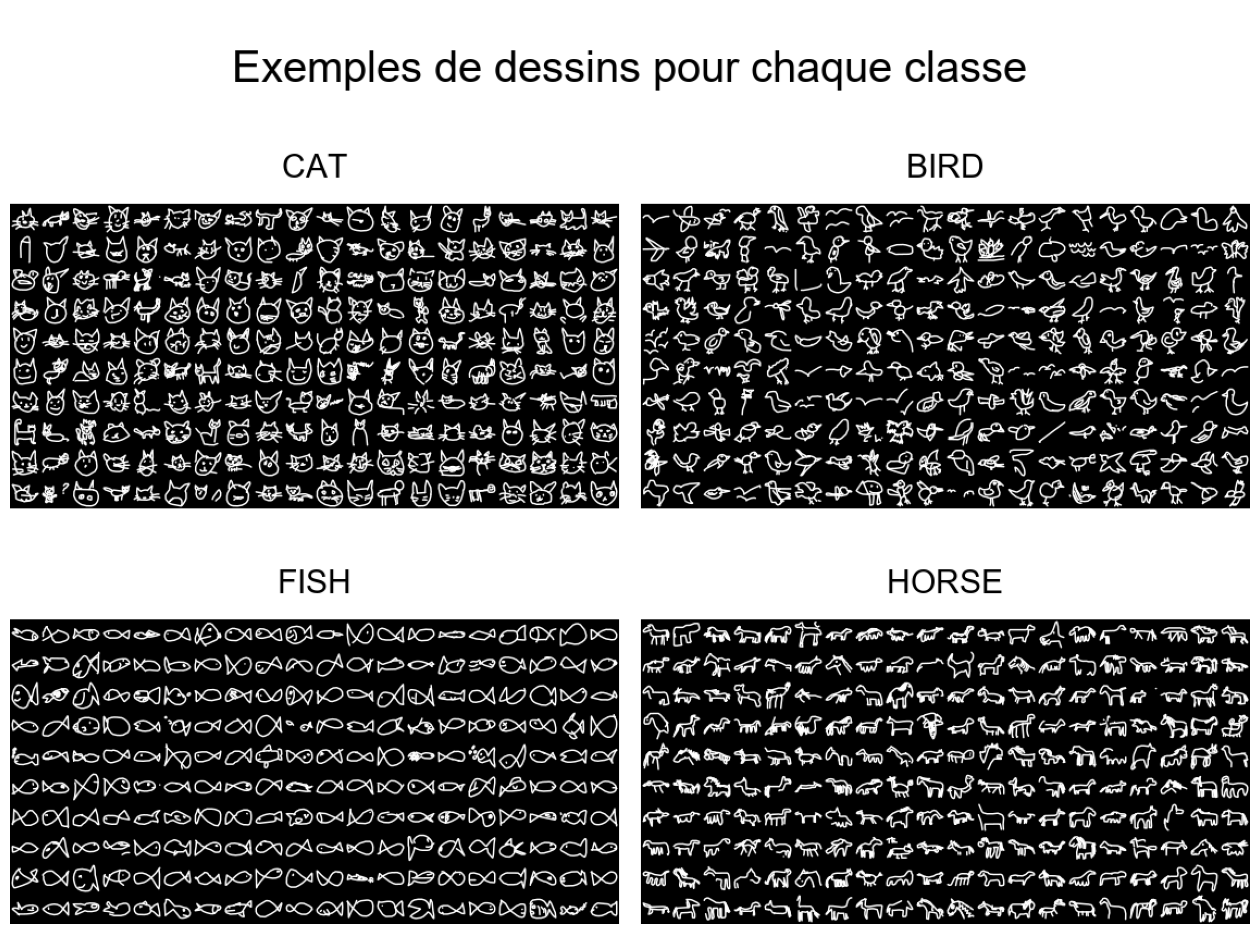

In [32]:
some_class_img = []
for i, name in enumerate(animaux):
    img_path = show_info.agregate_drawings(X, y, label=i, fname=name, outdir="animal", rows=10, cols=20)
    show_info.add_title(img_path, title=name.upper(), fontsize=30)
    some_class_img.append(img_path)  

big_img = show_info.combine_2x2(some_class_img, fname = "combined", outdir="animal")
show_info.add_title(big_img, title = "Exemples de dessins pour chaque classe", fontsize=40)
show_info.show_img(big_img)

En regardant de plus près les dessins, on peut voir que certains ne permettraient pas, même à un humain, de reconnaitre l'animal dessiné. 

Dans ce sens, sachant qu'un modèle de reconnaissance d'image nécessite naturellement énormément de données, et que nous sommes limités en puissance de calcul, nous allons prendre quelques temps pour trier les dessins ratés, avant de commencer à former nos modèles. 

### I.2. Filtrage et Rééquilibrage du dataset

#### I.2.1. Séparation des dessins ratés

On choisit ici d'écarter uniquement les dessins trop remplis ou trop vides, puisqu'ils sont faciles à écarter et que le dataset imparfait obtenu permettra de mieux souligner les différences de performances entre les modèles.

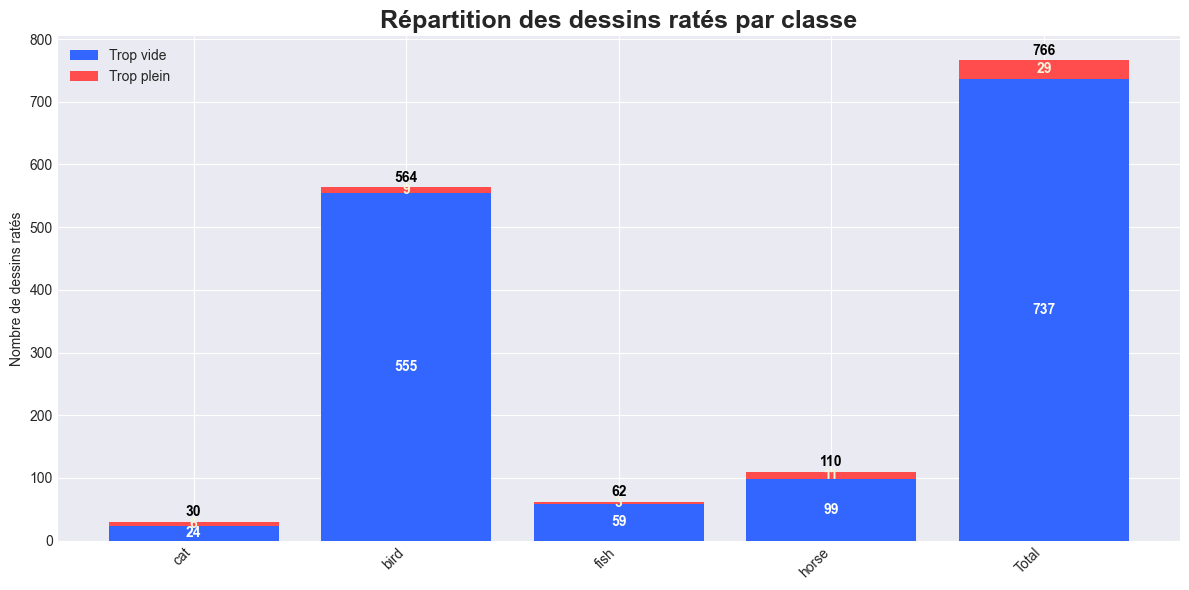

In [33]:
# 20 000 établit par expérience
def is_too_empty(img, min_threshold=20000):
    return img.sum() < min_threshold

# 70 000 établit par expérience
def is_too_full(img, max_threshold=70000):
    return img.sum() > max_threshold

bad_indices = []

for i, x in enumerate(X):
    img = x.reshape(28, 28)
    if is_too_empty(img) :
        bad_indices.append((i, y[i], 0))
    elif is_too_full(img) :
        bad_indices.append((i, y[i], 1))
        
show_info.plot_bad_drawing_bars(bad_indices, animaux)

On peut voir qu'avec ce filtre, on a déjà éliminé ($\frac{766}{4\times 6000}\simeq$) 3% des images du dataset. 

Tout particulièrement, on peut remarquer que le filtre a écarté énormément d'oiseaux "Trop vide". Penchons-nous sur les dessins écartés pour comprendre pourquoi.

#### I.2.2. Visualisation des dessins ratés

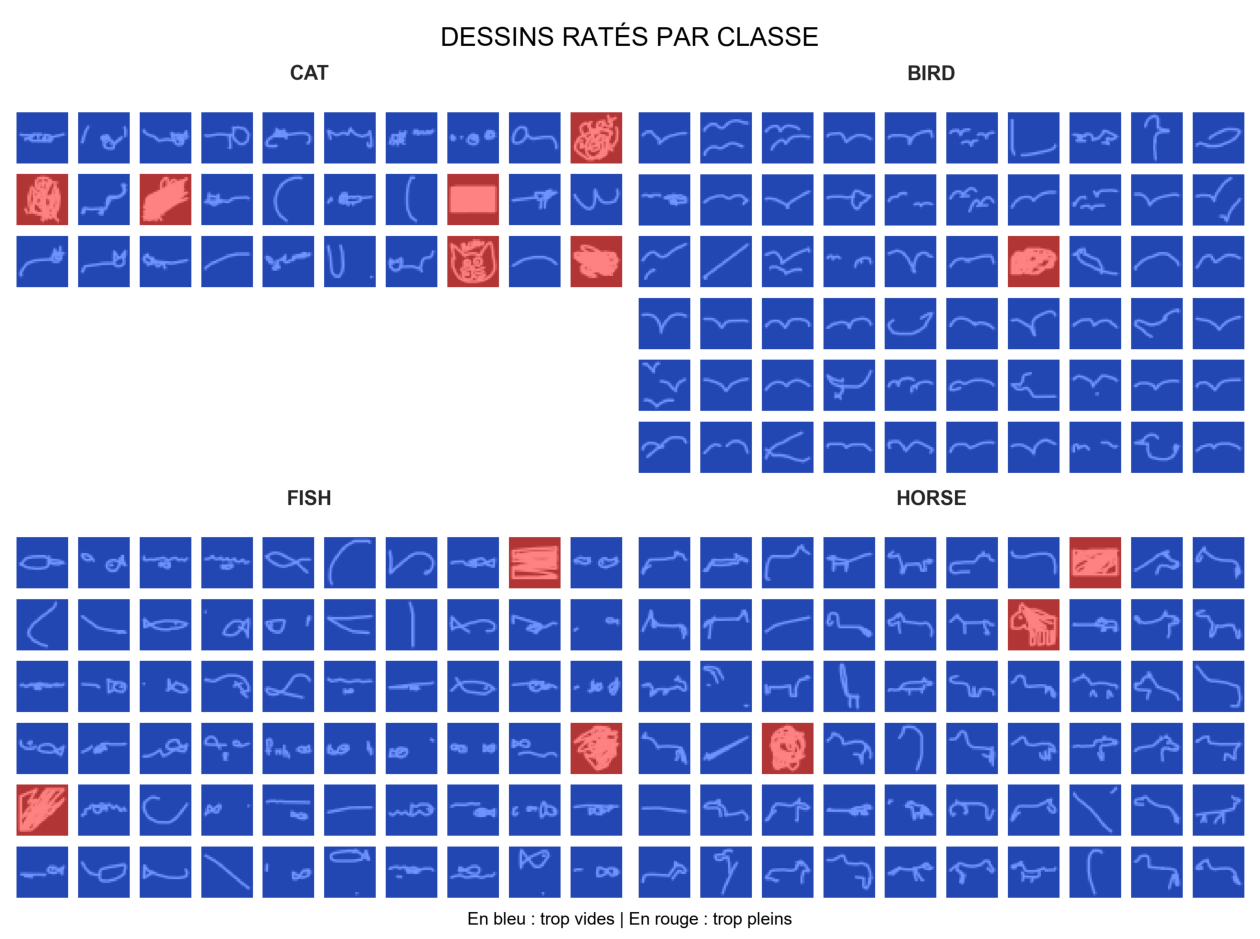

In [34]:
image_paths = []
for i, name in enumerate(animaux):
    image_paths.append(show_info.aggregate_colorize_bad_images(X, bad_indices, label_class=i, title=name,
                                                               outdir="animal/bad_images", cols=10, rows=6))

img = show_info.combine_2x2(image_paths, outdir="animal/bad_images", fname="bad_combined", padding=10)
show_info.add_title(img, title="DESSINS RATÉS PAR CLASSE", fontsize=60)
show_info.add_caption(img, "En bleu : trop vides | En rouge : trop pleins", fontsize=40)
show_info.show_img(img)

On comprend donc que beaucoup d'oiseaux ont été marqués comme "Trop vide", de par la manière de dessiner les oiseau en forme de "V". Ici, on choisira de restreindre notre modèle à des dessins majoritairement de corps d'oiseau en entier.

On relèvera également un nombre non négligeable de ratures, ce qui confirme notre intuition de trier les dessins.

#### I.2.3. Suppression des dessins ratés et rééquillibrage des classes

On peut donc désormais filtrer notre dataset pour écarter les dessins ratés.

In [35]:
bad_ids = {idx for idx, _, _ in bad_indices}

X_clean = np.array([x for i, x in enumerate(X) if i not in bad_ids])
y_clean = np.array([y[i] for i in range(len(y)) if i not in bad_ids])

classes, counts = np.unique(y_clean, return_counts=True)

print("Répartition de chaque classe après nettoyage :")
for i in range(nb_classes):
    print(f" - {animaux[i]} : {counts[i]}")

min_size = min(counts)
selected_indices = []

for c in classes:
    # indices de la classe c
    idx = np.where(y == c)[0]

    # on garde les min_size premiers
    selected_indices.extend(idx[:min_size])

# reconstruction
X_balanced = X[selected_indices]
y_balanced = y[selected_indices]

unique, counts = np.unique(y_balanced, return_counts=True)
    
print("\nRépartition de chaque classe après équilibrage :")
for i in range(nb_classes):
    print(f" - {animaux[i]} : {counts[i]}")

Répartition de chaque classe après nettoyage :
 - cat : 5970
 - bird : 5436
 - fish : 5938
 - horse : 5890

Répartition de chaque classe après équilibrage :
 - cat : 5436
 - bird : 5436
 - fish : 5436
 - horse : 5436


On divise finalement le dataset filtré et équilibré en un ensemble d'entraînement (70%) et un ensemble de test (30%), avec le même découpage pour tous les modèles.

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.3)

# Normalisation des données pour améliorer les performances des modèles
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Shape de X_train_scaled:", X_train_scaled.shape)
print("Shape de y_train:", y_train.shape)
print("Shape de X_test_scaled:", X_test_scaled.shape)
print("Shape de y_test:", y_test.shape)

Shape de X_train_scaled: (15220, 784)
Shape de y_train: (15220,)
Shape de X_test_scaled: (6524, 784)
Shape de y_test: (6524,)


## II. Baseline Linéaire : Régression Logistique 
---

### II.1. Vectorisation des images et Conséquences

Avant d'appliquer le premier modèle, il faut tout d'abord comprendre ce que l'on fait réellement en manipulant des images avec un algorithme linéaire. 

En effet, une image est un objet naturellement **bidimensionnel** de taille $h \times w$. Pour appliquer un modèle linéaire standard, on doit donc l'aplatir en un vecteur :

$$x \in \mathbb{R}^{h \times w} \quad \longrightarrow \quad \tilde{x} \in \mathbb{R}^{d}, \qquad d = h \times w = 784$$

Seulement, cette opération **détruit toute la structure spatiale de l'image**. Le pixel en position $(i, j)$ et celui en position $(i, j+1)$, pourtant voisins dans l'image, peuvent se retrouver à deux positions différentes dans le vecteur, sans que le modèle ne sache qu'ils étaient proches. Plus grave encore, si l'on applique une translation sur l'image le modèle pourrait ne plus être capable de reconnaitre le même dessin. Un modèle linéaire standard ne peut donc pas traiter les images en tant que telles, mais simplement comme des vecteurs de nombres.

### II.2. Rappel : Modèle de Régression logistique avec Softmax

Pour rappel, la régression logistique multiclasse, est l'extension naturelle de la régression logistique binaire que nous avons déjà étudiée. Pour $K$ classes, le modèle apprend une matrice de poids $W \in \mathbb{R}^{K \times d}$ et un vecteur de biais $b \in \mathbb{R}^K$. Ainsi, pour chaque exemple $x$, il calcule les **logits** $z = Wx + b \in \mathbb{R}^K$, puis les convertit en probabilités via la fonction softmax :

$$p_k = \frac{e^{z_k}}{\sum_{j=1}^K e^{z_j}}$$

La classe prédite est finalement celle avec la probabilité maximale : $\hat{y} = \arg\max_k p_k$.

La phase d'apprentissage consiste ainsi à minimiser la **cross-entropy** sur l'ensemble d'entraînement : $\nabla_W \mathcal{L} = x\,(p - y)^T$

D'après cette équation, on en déduit que l'apprentissage **dépend uniquement du produit scalaire entre le vecteur de pixels et les poids**. Dans ce sens, le modèle cherche juste une séparation linéaire dans $\mathbb{R}^{784}$, et ne peut donc pas représenter une frontière de décision qui dépend des relations spatiales entre les pixels.

### II.4. Implémentation et Analyse des résultats

Pour mieux comprendre les limites d'un modèle linéaire en vision par ordinateur, on va tenter d'entrainer un modèle à reconnaitre les 4 types d'image de notre dataset Quick, Draw!

In [37]:
model_LR = LogisticRegression(max_iter=2000)
model_LR.fit(X_train_scaled, y_train)

all_probs = model_LR.predict_proba(X_test_scaled)
preds, probs = np.argmax(all_probs, axis=1), np.max(all_probs, axis=1)
accuracy_LR = np.mean(preds == y_test)
print(f" ================= Accuracy du modèle Régression Linéaire : {accuracy_LR*100:.2f} % ================= ")

 ================= Accuracy du modèle Régression Linéaire : 70.85 % ================= 


L'accuracy de 71.29% montre donc que le modèle apprend à reconnaitre les images (les prédictions sont meilleures que de l'aléatoire : 25% pour 4 classes), mais ses performances plafonnent rapidement.

Pour comprendre d'où vient ce plafonnement, on peut visualiser un extrait des classifications fournies par le modèle sur le jeu de test.

Image sauvegardée dans : ./img/animal/predict\LR_predictions_80.png


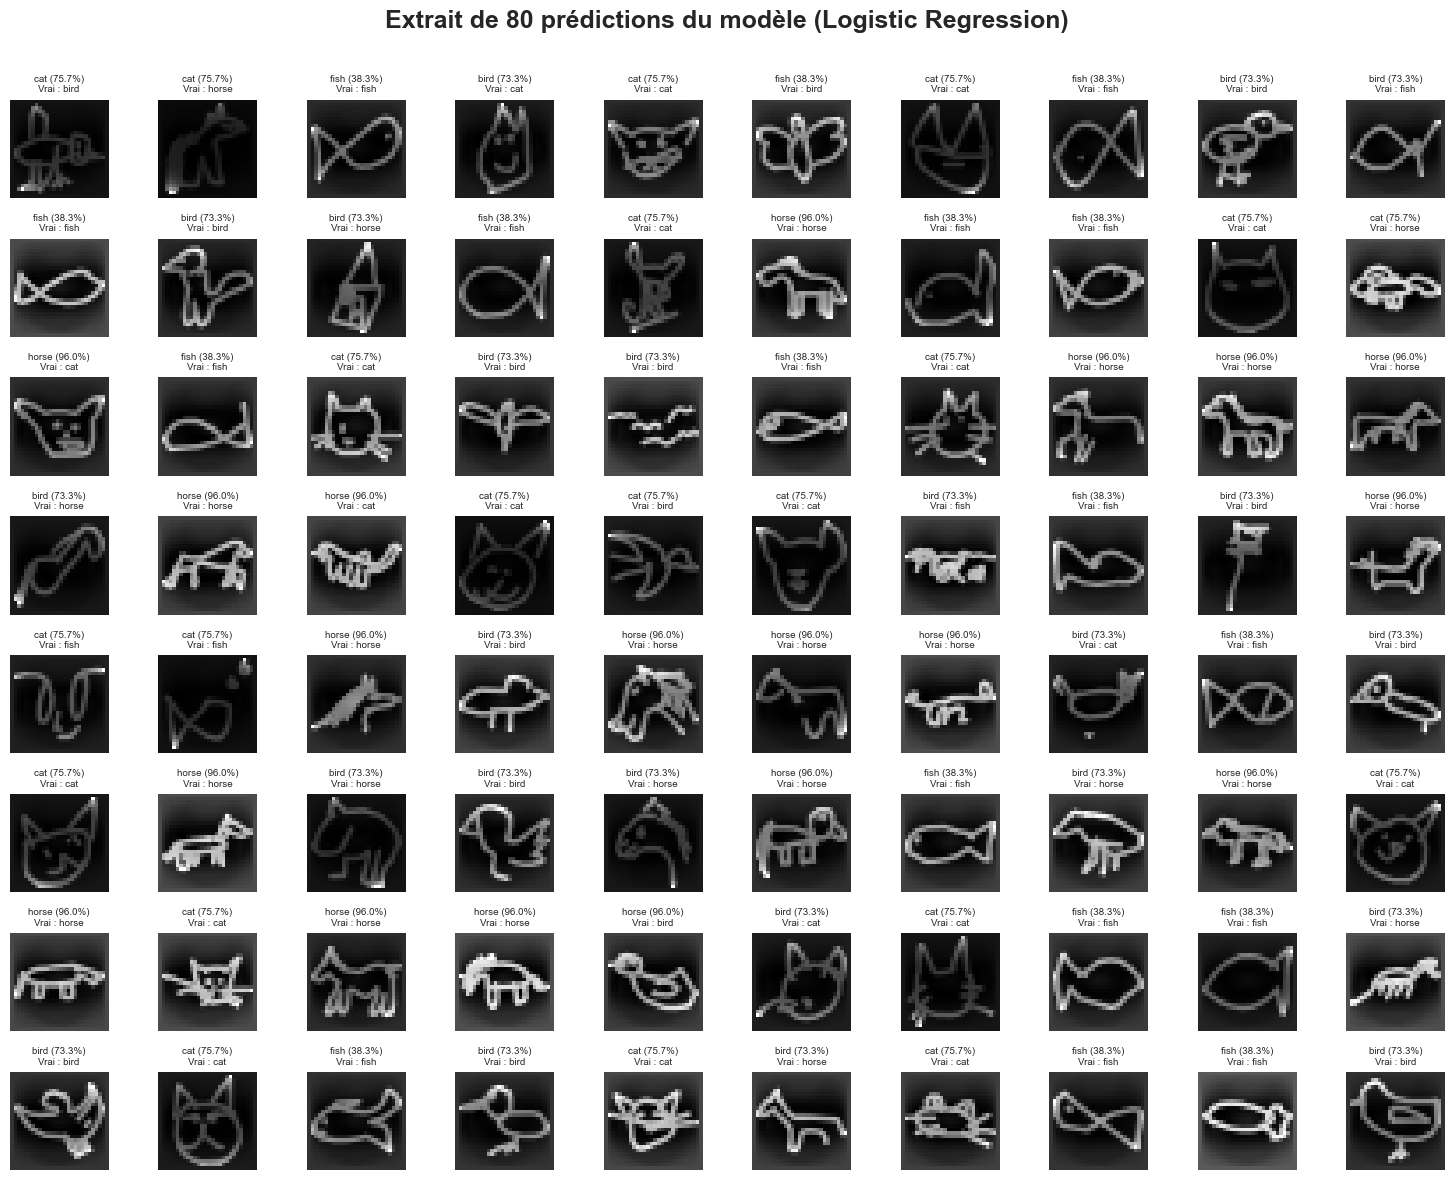

In [38]:
show_info.save_predictions_grid(X_test_scaled, y_test, preds, probs, animaux, rows=8, cols=10,
                                title="Extrait de 80 prédictions du modèle (Logistic Regression)",
                                save_name="LR_predictions_80", save_dir="./img/animal/predict")

Finalement, on voit que les erreurs de notre modèle se concentrent surtout autour des dessins d'animaux qui n'ont pas une "forme globale" habituelle. De plus, on peut remarquer que le modèle est très incertain sur les prédictions qu'il suggère.

Ces erreurs sont assez révélatrices des raisons du plafonnement de notre modèle : les doodles ne sont simplement pas linéairement séparables dans l'espace des pixels.

C'est pourquoi, nous allons nous intéresser en profondeur à un nouveau modèle, capable d'apprendre des représentations internes non linéaires : le perceptron multicouche.

## IIII. Perceptron Multicouche (MLP) *from Scratch*

---

Dans la section précédente, nous avons donc étudié un **modèle linéaire** de classification : $f(x) = W x + b$

Dans ce contexte, on cherchait à définir une séparation globale dans l’espace des pixels à l'aide d'un hyperplan. Or, comme nous l'avons vu, rien ne garantit qu'une structure linéaire y soit discriminante.

Formellement, si dans l'espace des pixels il n'existe pas de frontière de décision linéaire (ie. si la fonction cible $f^*$ est non linéaire), on peut trivialement affirmer que :
>  Toute classe linéaire $\mathcal{F}_{lin} = {x \mapsto W x + b}$ présentera une **erreur d’approximation irréductible**.

L'objectif principal de cette section sera ainsi de trouver comment enrichir cette classe fonctionnelle linéaire, afin d'obtenir un modèle avec une bonne approximation, tout en étant apprenable.

#### Pourquoi implémenter un réseau de neuronnes *from scratch* ?

On pourrait légitimement se demander pourquoi ne pas utiliser PyTorch ou Tensorflow directement pour entrainer un réseau de neuronnes, puisque ces modèles sont déjà bien plus optimisés que ce qui est réalisable dans un notebook. La réponse tient principalement à des objectifs pédagogiques. 

Contrairement aux précédentes méthodes employées, l'"algorithme" sous-jaccent du MLP présente une structure bien plus complexe, mais qui permet tout autant de comprendre comment le modèle apprend à reconnaitre des éléments. L'implémenter manuellement permet de vérifier que chaque gradient a un sens mathématique clair, de comprendre la structure modulaire des réseaux, et d'observer concrètement la dynamique d'apprentissage. Autrement dit, l'objectif de cette section sera de passer d'une simple utilisation d'un réseau de neurones, à une compréhension réelle de son fonctionnement. 

### III.1. Principe d'implémentation d'un MLP

#### III.1.1. Formulation fonctionnelle du problème et limites des classes linéaires

Le problème consiste donc à approximer, à partir d’un échantillon i.i.d. ${(x_i, y_i)}_{i=1}^n\sim \mathcal{D}$, une fonction inconnue : $f^* : \mathcal{X} \rightarrow \mathcal{Y}$, avec un espace d’entrée $\mathcal{X} \subset \mathbb{R}^d$ et un espace de sortie $\mathcal{Y} \subset \mathbb{R}^K$.

Dans ce sens, on cherchera parmi la classe de modèles $\mathcal{F}$, une fonction $\hat{f}$ qui minimise l'espérance de la perte sur la vraie distibution des données :
$$\hat{f}=\arg\min_{f \in \mathcal{F}}\mathbb{E}_{(x,y)\sim \mathcal{D}}[\ell(f(x), y)]$$

Le plus compliqué sera donc de trouver la classe $\mathcal{F}$ qui soit suffisament riche pour éviter le sous-apprentissage et suffisament simple pour éviter le sur-apprentissage et les problèmes d'optimisation.

#### III.1.2. Non-linéarité : ajout de couches cachées

##### Réseau à une couche cachée 

Pour dépasser les limites de la classe linéaire, on définit la classe :
$$\mathcal{F}_\text{MLP}=\left\{ x\mapsto \sum_{j=1}^{h}\alpha_j\sigma(w_j^Tx+b_j) \right\}$$

qui désigne la famille de fonctions réalisables par un perceptron multicouche (MLP) à une seule couche cachée de $h$ neurones.

Le plus intéressant est que d'après le **théorème d'approximation universelle** (*Cybenko (1989)* [[1]](#ref1), *Hornik (1991)* [[2]](#ref2)), on peut affirmer que pour toute fonction définit sur un compact $\mathcal{X} \subset \mathbb{R}^d$ et pour tout $\epsilon\gt 0$, il existe un réseau à une couche cachée $f\in\mathcal{F}_\text{MLP}$ tel que :
$$\sup_{x\in \mathcal{X}} \left| f(x)-f^*(x) \right|\lt \epsilon$$

Sous condition que $\sigma$ soit non polynomiale.

Le vrai problème de ce théorème est que ce résultat ne dit rien sur la taille de la couche cachée nécessaire.

##### Réseau à plusieurs couches cachées

Des travaux plus récents (*Telgarsky (2016)* [[3]](#ref3), *Montúfar et al. (2014)* [[4]](#ref4)) ont montré que la profondeur est essentielle pour implémenter un réseau de neurones efficacement. Concrètement, ces travaux affirment qu'un réseau profond peut représenter certaines fonctions avec un nombre de neurones polynomial, alors qu’un réseau peu profond nécessiterait une largeur exponentielle.

***Explications*** : *En effet, par exemple, avec $n$ neurones ReLU dans une seule couche, on peut définir $n$ hyperplans qui découpent l’espace jusqu’à $O(n^d)$ régions (si l’entrée est de dimension $d$). En fixant $d$, on retient surtout que le nombre de régions croît polynomialement avec $n$. Enfin, toujours en fixant $d$, un réseau ReLU de profondeur $L$ et de largeur $n$ peut créer environ $O(n^L)$ régions linéaires distinctes. La croissance est donc exponentielle en profondeur, mais seulement polynomiale en largeur.* 

Pour former un réseau de neuronnes à plusieurs couches, on commence donc par ajouter une non-linéarité $\sigma$ (*ReLU*, *tanh*, etc.) au modèle linéaire de classification $f(x) = W_1 x + b_1$ pour obtenir la couche d'activation : $h(x) = \sigma (W_1 x + b_1)$

On passe ensuite cette couche d'activation dans un second modèle linéaire, pour obtenir le MLP à une couche cachée :
$$f(x)=W_2 \, \sigma(W_1 x + b_1) + b_2$$

Puis on répète l'opération sur le nombre de couche cachée afin d'obtenir un MLP à $L$ couches cachées :
$$f_\theta(x)= W_L \,\sigma\,\left(W_{L-1}\,\sigma\!\left(\cdots\sigma(W_1 x + b_1)\right) + b_{L-1}\right) + b_L\in \mathbb{R}^K$$

Finalement, l'objectif de la phase d'apprentissage sera d'entrainer le réseau à équillibrer l'ensemble des paramètres $\theta=\left\{ W_1,b_1,\cdots,W_L,b_L \right\}$, de sorte à minimiser l'erreur du modèle pour la généralisation.

Pour notre problème de classification d'images $28\times 28$, on choisira donc d'utiliser une architecture à trois couches cachées, qui capturent des motifs de plus en plus abstraits :

$$784 \xrightarrow{W_1} 512 \xrightarrow{W_2} 256 \xrightarrow{W_3} 128 \xrightarrow{W_4} 10$$

#### III.1.3. Apprentissage : Approximation des paramètres et maximum de vraisemblance

Pour transformer les scores obtenus $f_\theta(x)\in\mathbb{R}^K$ en probabilité, on applique la fonction softmax sur les sorties de sorte à obtenir un modèle conditionnel : $p_\theta(y|x) = \text{softmax}(f_\theta(x))$

Dans ce sens, la phase d’apprentissage consistera à trouver le $\theta^*$ qui vérifie :
$$\theta^* = \arg\max_\theta \sum_{i=1}^n \log p_\theta(y_i | x_i)$$

Ce qui correspond, comme nous l'avons déjà vu, à minimiser la cross-entropy :
$$\mathcal{L}(\theta)=-\frac{1}{n}\sum_{i=1}^n\sum_{k=1}^Ky_{ik} \log p_{ik}$$

On est finalement face à un problème **d’optimisation non convexe** (qui peut contenir des minima locaux, des points selle et des vallées plates...), caractéristique des réseaux de neurones modernes.

Dans ce sens, pour mettre à jour les paramètres, on utilise généralement la descente de gradient, dont la dynamique s’écrit :
$$\theta_{t+1}=\theta_t - \eta \nabla_\theta \mathcal{L}(\theta_t)$$
où $\eta$ désigne le taux d’apprentissage.

En effet, plusieurs travaux récents ont permis de montrer que la descente de gradient reste efficace dans les réseaux profonds, même si les problèmes d'optimisation sont non-convexe :
* *Dauphin et al. (2014)* [[5]](#ref5) ont montré que les points selle jouent un rôle central dans la difficulté de l’optimisation, davantage que les minima locaux.
* *Kawaguchi (2016)* [[6]](#ref6) a démontré que, dans certains réseaux profonds mais linéaires, il n’existe pas de “mauvais” minima locaux : tous les minima locaux sont en fait des minima globaux.
* *Allen-Zhu et al. (2019)* [[7]](#ref7) ont établi que, sous des conditions de sur‑paramétrisation, la descente de gradient converge vers une solution satisfaisante, même dans des réseaux non linéaires.

En résumé, ces résultats soulignent que l’efficacité de l’apprentissage profond repose en grande partie sur le régime de sur‑paramétrisation (ie. imposer beaucoup plus de paramètres que nécessaire), qui rend l’optimisation plus favorable malgré la non‑convexité du problème.

#### III.1.4. Calcul du gradient : Rétropropagation

Pour entraîner un réseau de neurones profond par descente de gradient, on doit donc calculer le gradient de la perte par rapport à chacun des paramètres du modèle : $$\nabla_\theta \mathcal{L}(\theta_t)=\left(\frac{\partial \mathcal{L}}{\partial W^{(1)}}, \frac{\partial \mathcal{L}}{\partial b^{(1)}},\cdots,\frac{\partial \mathcal{L}}{\partial W^{(L)}}, \frac{\partial \mathcal{L}}{\partial b^{(L)}}\right)$$

Pour comprendre comment calculer ces dérivés partielles, partons des scores obtenus pour chaque classe : $f_\theta(x)=\begin{pmatrix}Z^{(L)} \\\vdots \\ Z^{(1)}\end{pmatrix}$

Comme nous l'avons vu, la dérivé de la cross-entropy par rapport au score (logits) d'une classe $k$, a une forme très simple : 
$$\delta^{(L)} = \frac{\partial \mathcal{L}}{\partial Z^{(L)}} = P - Y_{\text{onehot}}$$
où $P\in \mathbb{R}^{K \times B}$ est la distribution prédite et $Y_{\text{onehot}} \in \mathbb{R}^{K \times B}$ est la matrice des labels encodés en one-hot (ie. $Y_{i,j}=1$ si le dessin $i$ appartient à la classe $j$, et $0$ sinon).

Concrètement, ce terme mesure donc l’erreur finale, de sorte à ce que le gradient soit **positif** si le modèle **surestime** une classe et **négatif** s’il la **sous‑estime**. On note cette erreur de la pré-activation à la dernière couche $L$ : $\delta^{(L)}=\frac{\partial \mathcal{L}}{\partial Z^{(L)}}$.

Maintenant, si on dérive la perte par rapport aux poids de la couche de sortie $Z^{(L)} = W^{(L)} A^{(L-1)} + b^{(L)}$, on obtient :
$$\frac{\partial \mathcal{L}}{\partial W^{(L)}}=\frac{\partial \mathcal{L}}{\partial Z^{(L)}}.\frac{\partial Z^{(L)}}{\partial W^{(L)}}=\frac{\partial \mathcal{L}}{\partial Z^{(L)}}A^{(L-1)T} = \delta^{(L)} A^{(L-1)T}$$

On peut ainsi voir ré-apparaitre la structure générale : **gradient = erreur ($\delta^{(L)}$) $\times$ entrée ($A^{(L-1)T}$)**. 

Ensuite, pour la couche $L-1$, juste avant la couche de sortie, définie par :
$$\text{Activation : } A^{(L-1)} = \sigma(Z^{(L-1)})
\quad \text{et} \quad \text{Pré-activation : }
Z^{(L-1)}= W^{(L-1)} A^{(L-2)} + b^{(L-1)} $$ 

On calcule, dans un premier temps, la dérivée de la perte par rapport à l'activation : 
$$\frac{\partial \mathcal{L}}{\partial A^{(L-1)}}=\frac{\partial \mathcal{L}}{\partial Z^{(L)}}.\frac{\partial Z^{(L)}}{\partial A^{(L-1)}}=\delta^{(L)}.\frac{\partial Z^{(L)}}{\partial A^{(L-1)}} = \left(W^{(L)}\right)^T \delta^{(L)}$$

Puis, on utilise cette formule pour calculer la dérivée de la perte par rapport à la pré-activation :
$$\frac{\partial \mathcal{L}}{\partial Z^{(L-1)}}=\frac{\partial \mathcal{L}}{\partial A^{(L-1)}}\frac{\partial A^{(L-1)}}{\partial Z^{(L-1)}}=\frac{\partial \mathcal{L}}{\partial A^{(L-1)}} \odot \sigma'(Z^{(L-1)})=\left(W^{(L)}\right)^T \delta^{(L)} \odot \sigma'(Z^{(L-1)})$$

où $\sigma'$ représente la dérivée de l’activation (par exemple, pour $\sigma =\text{ReLU}$, $\sigma'(a)=\mathbb{1}_{a\gt0}$) et $\odot$ le produit élément par élément ou produit Hadamard.

On note donc le "signal" d'erreur de la couche $L-1$ : $$\delta^{(L-1)}=\frac{\partial \mathcal{L}}{\partial Z^{(L-1)}}=\left(W^{(L)}\right)^T \delta^{(L)} \odot \sigma'(Z^{(L-1)})$$ 

On peut donc voir que le signal d'erreur se calcule de manière récursive selon ce qu'on appelle **la règle de la chaine** : $\displaystyle (g\circ f)'=(g'\circ f)\times f'$

C'est tout le principe de la **rétropropagation** : l’erreur de la couche suivante est redistribuée vers la couche précédente en fonction des poids qui les relient.

De cette façon, on peut obtienir la dérivée de la perte par rapport aux poids $W^{(L-1)}$ et aux biais $b^{(L-1)}$, avec : 
$$\frac{\partial \mathcal{L}}{\partial W^{(L-1)}}=\frac{\partial \mathcal{L}}{\partial Z^{(L-1)}}.\frac{\partial Z^{(L-1)}}{\partial W^{(L-1)}}=\delta^{(L-1)}.\frac{\partial Z^{(L-1)}}{\partial W^{(L-1)}}=\delta^{(L-1)}\left(A^{(L-2)}\right)^T
\quad \text{et} \quad 
\frac{\partial \mathcal{L}}{\partial b^{(L-1)}}=\frac{\partial \mathcal{L}}{\partial Z^{(L-1)}}\frac{\partial Z^{(L-1)}}{\partial b^{(L-1)}}=\delta^{(L-1)}.\frac{\partial Z^{(L-1)}}{\partial b^{(L-1)}}=\delta^{(L-1)}$$


Finalement, en résumé, pour n'importe qu'elle couche $l = L, L-1, \dots, 1$, on obtient par rétropropagation récursive :
$$\boxed{\begin{matrix}
\delta^{(L)} &= P - Y_{\text{onehot}} \\
\longrightarrow \delta^{(l)} &= \left(W^{(l+1)}\right)^T \delta^{(l+1)} \odot \sigma'(Z^{(l)}) \\
\longrightarrow \frac{\partial \mathcal{L}}{\partial W^{(l)}} &= \delta^{(l)} A^{(l-1)T} \quad \text{et} \quad
\frac{\partial \mathcal{L}}{\partial b^{(l)}} &= \delta^{(l)}
\end{matrix}}$$

Dans ce sens, on comprend que la rétropropagation est essentiellement un **enchaînement de produits matriciels**, et c’est précisément cette structure qui a permis à l’apprentissage profond de se développer lorsque les GPU (initialement conçus pour le rendu graphique) ont offert une puissance de calcul massivement parallèle bien supérieure à celle des CPU. En effet, la théorie de la rétropropagation existait déjà depuis les années 1980, mais elle n’a réellement pris son essor qu’à partir de 2010, au moment où les GPU programmables (comme *CUDA* de *NVIDIA*, *2006*) sont devenus suffisamment puissants et accessibles pour entraîner des réseaux profonds à grande échelle.

#### III.1.5. Problème du vanishing / exploding gradient

Lorsque l’on entraîne un réseau profond, le gradient doit être rétropropagé depuis la couche de sortie jusqu’aux premières couches. À chaque étape, ce gradient est multiplié par la matrice de poids de la couche correspondante, ainsi que par la dérivée de la fonction d’activation.

Si l’on déroule cette propagation sur plusieurs couches, on obtient une expression du type :
$$\delta^{(l)} = \left(W^{(l+1)}\right)^TD^{(l+1)}\left(W^{(l+2)}\right)^TD^{(l+2)}\cdots \left(W^{(L)}\right)^TD^{(L)}\delta^{(L)}$$

où $D^{(k)}$ est une matrice diagonale contenant les dérivées $\sigma'(a^{(k)})$

On comprend donc que la norme du gradient dépend directement du produit des valeurs propres (ou des normes spectrales) des matrices $W^{(k)}$, $D^{(k)}$ successives.

Ainsi, si ces valeurs propres sont légèrement supérieures à 1, la norme du gradient augmentera à chaque itération, et le gradient finira par exploser (phénomène d'*exploding gradient*). A l'inverse, si elles sont légèrement inférieures à 1, le gradient s’annulera progressivement (*vanishing gradient*).

Pour éviter ces phénomènes, il est essentiel que les poids soient initialisés de manière à préserver la variance du signal lorsqu’il traverse les couches, aussi bien en avant (*forward pass*) qu’en arrière (*backward pass*).

Un résultat classique dû à *Glorot & Bengio* en 2010 [[8]](#ref8) (formule $(12)$) montre que, pour une couche linéaire avec $n_in$ entrées et $n_out$ sorties, une initialisation correcte doit satisfaire :
$$\text{Var}(W_{ij}) = \frac{2}{n_{in} + n_{out}}$$

C’est ce principe qui a ensuite conduit aux schémas d’initialisation modernes comme **Xavier** (pour les activations sigmoïdes ou tanh) ou **He** (pour les ReLU, avec $\text{Var}(W_{ij}) = \frac{2}{n_{in}}$).

Néanmoins, dans le cadre de réseaux ReLU, *He et al. (2015)* [[9]](#ref9) ont montré une initialisation des poids quelques peu différente. En effet, la variance de la fonction ReLU s'écrit : $\text{Var}(\text{ReLU}(a_i)) = \frac{1}{2} \text{Var}(a_i)$ 

Ainsi, pour des entrées $x_j$ centrées et de variance $\sigma^2$, et des poids $w_{ij}$ i.i.d. centrés de variance $\sigma_w^2$, on note la variance de la pré-activation $\text{Var}(a_i)= n_{\text{in}} \cdot \sigma_w^2 \cdot \sigma^2$, de sorte à ce que :

$$\text{Var}(\text{ReLU}(a_i)) = \frac{1}{2} n_{\text{in}} \cdot \sigma_w^2 \cdot \sigma^2$$

L'objectif est donc de conserver la variance égale à la variance du signal $\sigma^2$ d'une couche à l'autre. Pour ce faire, on impose donc :
$$\frac{1}{2} \cdot n_{\text{in}} \cdot \sigma_w^2 = 1 \qquad \text{ soit,}\quad \sigma_w^2 = \frac{2}{n_{\text{in}}}$$

On initialise ainsi $W_l \sim \mathcal{N}\left(0,\; \frac{2}{n_{\text{in}}}\right)$, ce que l'on traduira en pratique par : `self.W[l] = np.random.randn(...) * np.sqrt(2.0 / fan_in)`

#### III.1.6. Compréhension intuitive des réseaux ReLU

Les réseaux de neurones utilisant la fonction d’activation ReLU possèdent une **interprétation géométrique** particulièrement élégante. En effet, contrairement aux activations lisses comme tanh ou sigmoid, la ReLU introduit une discontinuité de dérivée en zéro, ce qui permet à chaque neurone de découper l’espace d’entrée en régions distinctes.

Un réseau ReLU est donc une fonction affine par morceaux, dont les morceaux sont déterminés par les activations des neurones ($w^T x + b > 0$). Le réseau produit alors une partition polytopique : l’espace d’entrée est découpé en un **grand nombre de régions convexes** (des polytopes), et sur chacune de ces régions, la fonction du réseau est **strictement affine**. 

Comme on l'a expliqué, *Montúfar et al. (2014)* [[4]](#ref4) ont montré que le nombre de régions affines qu’un réseau ReLU peut créer augmente exponentiellement avec la profondeur. Plus précisément, un réseau profond peut représenter un nombre de régions affines de l’ordre de : $\Omega\left( \prod_{l=1}^{L}\frac{n_l}{n_{l-1}} \right)$


#### III.1.7. Capacité de généralisation du réseau

L'une des questions centrales de l’apprentissage automatique est de comprendre pourquoi un réseau de neurones généralise. Dans ce sens, pour analyser cette capacité de généralisation, plusieurs outils théoriques ont été développés au fil des années :
* **La dimension de VC (Vapnik–Chervonenkis)** : La dimension de VC mesure la capacité d’un modèle à pulvériser (*shatter*) un ensemble de points, c’est‑à‑dire à les séparer selon n’importe quel étiquetage. Plus la dimension de VC est grande, plus le modèle est capable de représenter des fonctions complexes. Cependant, pour les réseaux modernes, cette dimension est souvent gigantesque, ce qui rend cet outil difficile à utiliser directement.

* **Les bornes PAC (Probably Approximately Correct)** : Le cadre PAC fournit des garanties de généralisation en fonction de la capacité du modèle et de la taille de l’échantillon. Là encore, appliquées naïvement aux réseaux profonds, ces bornes deviennent très lâches, car elles dépendent souvent du nombre total de paramètres.

* **La Rademacher complexity** : Cet outil mesure la capacité d’un modèle à corréler ses prédictions avec du bruit aléatoire. Une complexité de Rademacher élevée signifie que le modèle peut facilement sur‑apprendre du bruit, ce qui est un signe de surcapacité (et qui n'a rien de positif).

Ces outils ont donc montré que tous que les réseaux de neurones profonds ont une capacité théorique énorme, parfois bien trop grande par rapport à la taille des jeux de données. Dans ce sens, un modèle aussi flexible devrait sur‑apprendre systématiquement.

Pourtant, dans la pratique, ils généralisent souvent paradoxalement très bien.

##### Normalisation des poids

Face à ce paradoxe, *Bartlett et al. (2017)* [[10]](#ref10) ont cherché à comprendre quels sont les mécanismes qui permettent à des réseaux massivement sur‑paramétrés de tout de même bien généraliser. Leur analyse montre que l’essentiel ne réside ni dans le **nombre total de paramètres**, ni dans la **profondeur**, ni même dans la **largeur** du réseau, mais dans la **norme des matrice de poids** apprises au cours de l’entraînement. 

En étudiant notamment la norme spectrale, les normes de Frobenius et certains produits de normes le long des couches, ils démontrent que la généralisation dépend avant tout de la “taille” des poids, et non de la taille brute de l’architecture.

Ainsi, si les poids restent “petits” selon ces normes, alors même un réseau massivement sur‑paramétré peut avoir une capacité effective modérée, et donc généraliser correctement.

Par dessus, on a pu observer empiriquement que la descente de gradient tend naturellement à sélectionner des solutions à faible norme, même sans régularisation explicite.

En résumé, on peut en conclure que les réseaux sur‑paramétrés peuvent bien généraliser parce que l’optimisation les conduit vers des solutions simples (à faible norme), même si l’espace des solutions possibles est immense.

Maintenant que nous avons abordé les principes de base d'un MLP, on va pouvoir examiner plusieurs choix de conception, comme l’usage du mini‑batch, de l'optimisateur Adam, l’introduction du dropout ou d’autres mécanismes qui améliorent la stabilité et la performance du modèle. L’objectif ici sera de comprendre en détail pourquoi ces techniques sont nécessaires et comment elles influencent l’apprentissage.


### III.2. Approfondissement et optimisation

#### III.2.1. Mini-batch : Dynamique stochastique d'apprentissage

##### III.2.1.a. Différentes stratégies pour calculer le gradient : Online learning, Offline learning et Batch learning

On distingue plusieurs méthodes pour entraîner un modèle à partir de données, et chacune repose sur une manière différente d’exploiter les exemples disponibles.

Par exemple, on peut entrainer notre modèle dans un contexte d'*online learning*, où le modèle met à jour ses paramètres après chaque nouvel exemple. C’est un apprentissage très réactif, presque instantané, qui convient bien aux flux de données continus. Cependant, ce traitement séquentiel permet à chaque point peut d'influencer fortement la trajectoire d’apprentissage, ce qui rend la méthode sensible au bruit et parfois instable.

A l'inverse, dans un contexte d'*offline learning*, on attend de disposer de l’ensemble du dataset avant de calculer le gradient global. On peut donc transformer les opérations séquentielles de l'online learning en opérations matricielles. Pour ce faire, on peut profiter de l'efficacité computationnelle de NumPy, qui délègue ses opérations matricielles à des bibliothèques hautement optimisées (BLAS, OpenBLAS, MKL) qui exploitent les instructions vectorielles du processeur et la hiérarchie de caches mémoire.

Néanmoins, en pratique, même lorsque l'ensemble du dataset est disponible à l'entrainement, on ne traite généralement pas la totalité du dataset à chaque itération. En effet, le gradient calculé sur le dataset complet est certes exact, mais il pointe vers le minimum de la loss sur les données d'entraînement, pas nécessairement vers un bon minimum pour la généralisation. 

C'est pourquoi, on utilisera plutôt un modèle par **mini-batch** $\{(x^{(1)}, y^{(1)}), \ldots, (x^{(B)}, y^{(B)})\}$ de taille $B$, qui remplace le gradient exact, par son **estimateur stochastique** :

$$\nabla_\theta \mathcal{L}(\theta) = \frac{1}{N}\sum_{i=1}^{N} \nabla_\theta \mathcal{L}^{(i)}(\theta) \quad \rightarrow \quad \hat{\nabla}_\theta \mathcal{L} = \frac{1}{B}\sum_{i=1}^{B}\nabla_\theta \mathcal{L}^{(i)}$$

L'avantage de cette estimation est qu'elle est **non biaisée** : son espérance sur tous les mini-batches possibles est égale au vrai gradient $\nabla_W \mathcal{L}$. De plus, elle est **moins bruitée** que l’estimation obtenue à partir d’un seul exemple, car sa variance est réduite d'un facteur $B$. Dans ce sens, plus le batch est grand, plus l’estimation est stable.

##### III.2.1.b. Descente de gradient stochastique (SGD) : trouver le bon minima

Comme le gradient n’est plus exact, l’itération d’apprentissage peut être vue comme une descente de gradient perturbée par un terme aléatoire, appelée **descente de gradient stochastique** :
$$\theta_{t+1}= \theta_t\eta\left(\nabla_\theta \mathcal{L}(\theta_t)+\xi_t\right)$$

où $\xi_t$ est un terme de bruit centré, de variance proportionnelle à $\frac{1}{B}$. 

C'est ce bruit qui permet au modèle d'explorer l’espace des paramètres et l'empêche de s’enfermer dans des minima très étroits (*sharp minima*) qui généralise mal (*Keskar et al., 2017* [[11]](#ref11)).

Pour comprendre cette distinction entre minima étroits et minima larges, il suffit d’examiner la géométrie locale du paysage de perte à l’aide du hessien $H = \nabla^2 \mathcal{L}(\theta)$. Un minimum est dit **sharp** si la perte augmente rapidement dès que l’on s’éloigne du point, autrement dit lorsque les valeurs propres dominantes de $H$ sont grandes. A l'inverse, il est dit **flat** si la perte reste faible dans un voisinage plus étendu, donc si les valeurs propres de $H$ sont plus faibles.

La méthode par mini‑batch est ainsi particulièrement intéressante parce qu’elle injecte, au cours de l’apprentissage, un bruit structuré qui agit comme un mécanisme d’exploration. Ce bruit empêche la trajectoire d’apprentissage de suivre aveuglément la pente locale et l’aide à parcourir différentes régions du paysage de perte, favorisant l’arrivée dans des minima plus larges.

##### III.2.1.c. Exploration libre du paysage de perte : comprendre l'influence de la taille des mini-batch

Afin de mieux comprendre l'effet du bruit introduit par les mini‑batches, il est utile de voir la fonction de perte comme une **quantité d’énergie**, une idée directement empruntée à la physique statistique.

Dans ce domaine, un système $\theta$ (par exemple un ensemble de particules) est décrit par une fonction d’énergie $E(\theta)$, et les configurations les **plus probables** sont celles qui **minimisent cette énergie**. La distribution des configurations d'énergie suit alors la loi de Boltzmann :
$$p(\theta)\propto\exp\left(-\frac{E(\theta)}{T}\right)$$

où $T$ représente la température, c'est-à-dire la mesure de l’intensité de l'agitation microscopique. Plus la température est élevée, plus les particules bougent vite et explorent un grand nombre de configurations possibles. Ainsi, dans l’apprentissage stochastique, l'agitation thermique provient du **bruit introduit par les mini‑batches**. 

Pour relier cette température au bruit de SGD, on peut s'appuyer sur le régime de petit pas d’apprentissage (lorsque $\eta$ est petit), qui approche la dynamique discrète de SGD par une **équation différentielle stochastique (SDE)** :
$$d\theta= \nabla_\theta \mathcal{L}(\theta)\,dt+\sqrt{\frac{\eta}{B}}\,\Sigma^{1/2}(\theta)\, dW_t$$

où $dW_t$ est un **mouvement brownien**, c’est‑à‑dire un mouvement composé d’une infinité de **petites secousses aléatoires**, et où $\sqrt{\frac{\eta}{B}}dW_t$ mesure l’amplitude instantanée du bruit.

Comme la température correspond à la variance de ces fluctuations, elle est proportionnelle au carré de cette amplitude. On obtient donc :
$$T\propto (\sqrt{\frac{\eta}{B}})^2=\frac{\eta}{B}$$

Finalement, on comprend que la température effective du système décroît lorsque la taille du batch augmente. Dans ce sens, pour un de **petits batch**, le bruit est faible et l'**exploration est plus limitée**, et peut donc s'"échapper" des **minima étroits** (*sharp minima*). À l’inverse, lorsque le batch est très grand, la température devient faible et la trajectoire suit presque exactement la pente locale, on peut alors se retrouver piégée dans ces *sharp minima*, qui sont souvent associées à une moins bonne généralisation.

Augmenter indéfiniment $B$ n’améliore donc pas nécessairement la généralisation.

C'est pourquoi, on choisira donc d'utiliser des batch de taille $B = 64$, afin de garder une parallélisation des opérations efficace, tout en conservant suffisamment de bruit stochastique pour ne pas rester piégé dans d'étroits minima locaux.

**Note** : À chaque *epoch* (c'est-à-dire à chaque passage complet sur l’ensemble des données d’entraînement), les données sont mélangées aléatoirement (*shuffle*) pour s'assurer que l'estimateur de gradient reste non biaisé en moyenne sur l'entraînement.

#### III.2.2. Optimiseur Adam : au-delà du taux d'apprentissage fixe

##### III.2.2.a. Limites d'une métrique euclidienne fixe pour l'apprentissage

Dans la descente de gradient classique, tous les paramètres sont mis à jour avec le même taux d’apprentissage :
$$\theta_{t+1}=\theta_t-\eta \,g_\theta$$

Seulement, cette approche ignore complètement tout d'abord que les **gradients n’ont pas la même échelle** selon les paramètres (par exemple les paramètres des premières couches reçoivent des gradients systématiquement plus petits que ceux des dernières couches), mais aussi que le **paysage de perte est anisotrope**, c'est-à-dire que certaines directions sont très courbées et d’autres presque plates. 

Conserver un taux d'apprentissage constant n'a donc pas vraiment de sens.

Pour remédier à cela, l’optimiseur **Adam** (*Adaptive **Moment** Estimation*, Kingma & Ba, 2015 [[12]](#ref12)) attribue à chaque paramètre un taux d’apprentissage adapté, en tenant compte de la manière dont son gradient a évolué au fil du temps, grâce à des moyennes mobiles exponentielles (EMA).

##### III.2.2.b. EMA : Adapter le pas selon le gradient précédent

Concrètement, une EMA suit l’évolution d’une quantité tout en lissant les grandes fluctuations. Elle se met à jour selon : 
$$s_t=\beta s_{t-1} + (1-\beta)x_t$$

où $x_t$ est la nouvelle valeur observée, $s_{t-1}$ est la moyenne lissé au temps précédent et où $\beta$ contrôle la vitesse d’oubli (proche de 1 = lissage fort).

L'EMA permet ainsi de donner plus de poids aux valeurs récentes, afin de stabiliser des gradients bruités.

Dans ce sens, à chaque étape $t$, Adam maintient les deux EMA du **gradient** et du **carré du gradient**, pour chaque paramètre $\theta$ :

$$m_t = \beta_1 m_{t-1} + (1 - \beta_1)\, g_t \quad \text{et}\quad v_t = \beta_2 v_{t-1} + (1 - \beta_2)\, g_t^2$$

où $g_t = \nabla_\theta \mathcal{L}_t$ est le gradient courant.

##### III.2.2.c. Correction du biais d’initialisation

Cependant, comme ces deux quantités valent zéros à l'initialisation, les premières EMA sous‑estiment systématiquement les moments réels et mettent du temps à se rapprocher de la vraie moyenne. 

Pour corriger ce retard d’accumulation, Adam applique une normalisation qui tient compte du nombre d'étapes effectuées :

$$\hat{m}_t = \frac{m_t}{1 - \beta_1^t} \qquad \hat{v}_t = \frac{v_t}{1 - \beta_2^t}$$

Ainsi, au début de l'entraînement ($t$ petit), les termes $1 - \beta_1^t$ et $1 - \beta_2^t$ sont proches de zéro, ce qui amplifie fortement $\hat{m}_t$ et $\hat{v}_t$ pour compenser le biais initial. Puis, après quelques dizaines d'itérations, $\beta_1^t$ et $\beta_2^t$ deviennent négligeables et la correction n'a plus d'effet.

La mise à jour finale est alors :

$$\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{\hat{v}_t} + \varepsilon}\, \hat{m}_t$$

Adam remplace donc le **gradient** instantané par une **direction moyenne lissée** $\hat{m}_t$, ce qui stabilise les mises à jour. De plus, il ajoute un terme $\frac{1}{\sqrt{\hat{v}_t} + \varepsilon}$ qui ajuste automatiquement l’échelle du pas pour chaque paramètre, en fonction de la variance locale du gradient (une variance élevée implique un petit pas d'apprentissage).

Dans ce sens, la descente s'effectue ainsi selon la métrique (non-euclidienne) définie par la matrice diagonale : $D_t = \mathrm{diag}\,\left(\frac{1}{\sqrt{\hat{v}_t} + \varepsilon}\right)$

On peut donc rapprocher le mécanisme de rectification des poids de l'algorithme d'Adam, à une **approximation diagonale de la matrice de Fisher**, utilisée dans les méthodes de *Natural Gradient*.

En résumé, Adam combine un lissage temporel du gradient et un ajustement adaptatif de l’échelle des pas, ce qui lui permet de mieux suivre la géométrie locale du paysage de perte et d’accélérer la convergence.

**Note** : Les hyperparamètres $\beta_1 = 0.9$, $\beta_2 = 0.999$ et $\varepsilon = 10^{-8}$ sont les valeurs recommandées par les auteurs.

##### III.2.2.d. Limites théoriques d’Adam

Malgré son efficacité pratique, plusieurs travaux ont mis en évidence certaines limites théoriques. D’abord, il peut **ne pas converger** sur certains problèmes convexes simples, en raison de la manière dont les poids adaptatifs modifient la dynamique de l’optimisation. Ensuite, il a tendance à trouver des solutions avec une **marge plus faible** que celles obtenues par SGD, ce qui peut nuire à la généralisation. Enfin, Adam peut **sur‑adapter** certains paramètres peu fréquemment mis à jour, car son mécanisme d’adaptation amplifie parfois excessivement les directions rares.

Pour ces raisons, dans des contextes d’entraînement à grande échelle, il est courant d’utiliser Adam pour la phase initiale (pour sa rapidité et sa stabilité), puis de basculer vers une **SGD avec momentum** pour les dernières étapes, afin d’obtenir de meilleures propriétés de généralisation.

Dans ce contexte pédagogique, Adam demeure néanmoins un choix **robuste, stable et surtout simple à utiliser**. 

#### III.2.3. Dropout : surapprentissage et régularisation par sous-réseaux aléatoires

Le dropout (*Srivastava et al., 2014* [[13]](#ref13)) est une technique de régularisation lors de l'entrainement, qui consiste à **désactiver de manière aléatoire une fraction des neurones** à chaque passe avant, afin de **limiter le surapprentissage** dans les réseaux neuronaux profonds. 

Formellement, on applique à la matrice d'activation $A \in \mathbb{R}^{h \times B}$, un masque binaire dont les entrées sont tirées indépendamment selon une loi de Bernoulli :

$$\tilde{A} = A \odot M \qquad M_{ij} \sim \text{Bernoulli}(1 - p) \text{ i.i.d.}$$

où $p$ est la probabilité de désactivation, et où $\odot$ désigne le produit élément‑par‑élément (ou Hadamard product). 

##### III.2.3.a. Optimiser l'espérance de la perte : interprétation bayésienne du problème

L’idée est que chaque masque définit un sous‑réseau particulier, et comme un nouveau masque est échantillonné à chaque batch, l’entraînement correspond en réalité à l’optimisation conjointe d’un très grand ensemble de sous‑réseaux partageant les mêmes poids.

Ainsi l’entraînement avec dropout revient à optimiser l’espérance : $\mathbb{E}*{M}\left[\mathcal{L}(f*{\theta, M}(x), y)\right]$

Cette formulation conduit ainsi, d'après *Gal & Ghahramani (2016)* [[14]](#ref14), à une interprétation bayésienne du problème : le dropout peut être vu comme une approximation variationnelle d’un réseau bayésien, où la distribution sur les poids est approchée par un mélange discret induit par les masques. 

Dans ce sens, le dropout ne se contente pas d’ajouter du bruit au modèle, mais introduit une forme d’incertitude épistémique et agit comme une moyenne d’ensemble implicite, ce qui réduit la variance du modèle et améliore sa capacité de généralisation.

##### III.2.3.b. Inverted dropout : conserver l’échelle des activations

Un détail important concerne l’échelle des activations. Pendant l’entraînement, comme une fraction $p$ des neurones est désactivée, les activations sont en moyenne réduites d’un facteur $(1-p)$. Si l’on retire le dropout à l’inférence, les activations deviennent alors trop grandes, ce qui crée une incohérence entre les distributions d’activations entre entraînement et test et qui peut nuire à la stabilité du réseau et dégrader ses performances.

L’inverted dropout corrige ce problème en rescalant les activations dès l’entraînement :
$$\tilde{A} = \frac{A \odot M}{1 - p}$$

Ce choix garantit que l’espérance des activations est préservée ($\mathbb{E}[\tilde{A}_{ij}] = A_{ij}$), de sorte à ce que le réseau complet puisse être utilisé tel quel à l’inférence, sans masque ni rescaling supplémentaire. 

Néanmoins, on pourra tout de même remarquer que la variance de l'activation devient : $\text{Var}(\tilde{A}_{ij})= \frac{p}{1-p} A_{ij}^2$

Le dropout introduit donc une variance proportionnelle à la magnitude de l’activation. Ainsi, les neurones fortement activés sont davantage perturbés, ce qui limite leur domination et encourage une **répartition plus homogène de l’information** au sein du réseau. 

#### III.2.4 Rétropropagation et notion de cache

L'introduction des mini-batches et du dropout nécessite finalement d'étendre les formules de rétropropagation dérivées précédemment. La règle de chaîne s'applique toujours, mais deux points demandent une attention particulière.

D'abord, dans le cas mini-batch, la rétropropagation se fait par des opérations qui reprennent les matrices de pré-activation $Z_l$ et d'activation $A_l$. Pour la couche $l$, le signal d’erreur rétropropagé est donné par : 
$$\delta^{(l)}=\left(W^{(l+1)}\right)^T \delta^{(l+1)} \odot \sigma'(Z^{(l)})$$

Les gradients des poids deviennent :
$$\frac{\partial \mathcal{L}}{\partial W_l}=\frac{1}{B}\delta_l A_{l-1}^T\qquad
\frac{\partial \mathcal{L}}{\partial b_l}=\frac{1}{B}\delta_l \mathbf{1}_B$$

où $\mathbf{1}_B$ est un vecteur colonne de taille $B$ rempli de 1.

Ensuite, concernant le dropout, de la même manière, le masque $M$ utilisé lors de la passe arrière doit être **exactement le même** que lors de la passe avant. 

En effet, le dropout définit une opération déterministe conditionnellement au masque : $\tilde{A} = A \odot M / (1-p)$, donc la dérivée de cette opération par rapport à $A$ dépend aussi du masque : $\frac{\partial \tilde{A}}{\partial A}=M / (1-p)$. Si l'on tirait un nouveau masque lors de la rétropropagation, on calculerait le gradient d'une fonction différente de celle effectivement évaluée lors de la passe avant.

Dans ce sens, pour rendre les calculs de la rétropropagation possibles, toutes les quantités intermédiaires de la passe avant (pré-activations $Z_l$, activations $A_l$, masques de dropout $M_l$) doivent être mémorisées. 

On doit donc ajouter un dictionnaire `cache` dans l'implémentation, pour jouer le rôle d'un **graphe de calcul** minimal, en enregistrant le chemin emprunté par les données pour que la rétropropagation puisse le remonter. 

Ce principe est précisément celui qui sous‑tend les frameworks modernes tels que *PyTorch*, *TensorFlow* ou *JAX*. Leur mécanisme d’**automatic differentiation** (*autograd*) construit dynamiquement un graphe de calcul, enregistre les opérations effectuées, puis propage automatiquement les gradients. Implémenter manuellement un cache permet ainsi de comprendre en profondeur ce que réalise une instruction comme `backward()` dans ces frameworks, pourquoi certaines opérations doivent être différentiables, et comment les gradients circulent réellement dans un réseau profond.

Dans la suite, nous allons donc enfin pouvoir implémenter ce modèle from scratch en NumPy, afin d’observer concrètement les performances du modèle sur le dataset Quick Draw! et de comparer ces résultats à la baseline linéaire de régression logisitique.


---

### III.3. Implémentation complète en NumPy

#### III.3.0. Fonctions de service pour les réseaux de neuronne

On commence par définir les fonctions de base : `relu`, `relu_deriv`, `softmax` et `cross_entropy`.

On définit ces fonctions en dehors de la classe, puisque celles-ci nous servirons également pour le futur modèle CNN. On garde ainsi une architecture simple et modulaire, en séparant les classes qui encapsulent l’état, et les fonctions libres qui encapsulent la logique.

Pour rappel, la fonction `cross_entropy` calcule la moyenne : $-\frac{1}{B}\sum_{i=1}^{B} \log\left(P_{Y_i,\, i}\right)$, où $P_{Y_i,i}$ est la probabilité prédite pour la classe correcte $Y_i$ de l’exemple $i$.

In [39]:
def relu(x):
    return np.maximum(0, x)

def relu_deriv(x):
    return (x > 0).astype(np.float32)

def softmax(z):
    e = np.exp(z - np.max(z, axis=0, keepdims=True))
    return e / np.sum(e, axis=0, keepdims=True)
    
def cross_entropy(P, Y):
    """
    P : (out_dim, batch_size)
    Y : (batch_size,)   
    """
    batch_size = Y.shape[0]
    # Pour chaque exemple, on prend la probabilité associée à la classe correcte
    correct_probs = P[Y, np.arange(batch_size)]
    return -np.mean(np.log(correct_probs + 1e-12))

On définit également une classe pour l'optimiseur Adam, qui elle aussi sera réutilisée pour le CNN.

#### Optimiseur Adam

In [40]:
class Adam:
    def __init__(self, params, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.t = 0

        self.params = params    # [{"W":..., "b":...}, ...]

        self.m = []
        self.v = []
        for p in params:
            self.m.append({"W": np.zeros_like(p["W"]), "b": np.zeros_like(p["b"])})
            self.v.append({"W": np.zeros_like(p["W"]), "b": np.zeros_like(p["b"])})

    def step(self, grads):
        ''' grad : [{"W": dW, "b": db}, ...] '''
        self.t += 1
        lr_t = self.lr * np.sqrt(1 - self.beta2**self.t) / (1 - self.beta1**self.t)

        for i, g in enumerate(grads):
            dW, db = g["W"], g["b"]

            # Moments
            self.m[i]["W"] = self.beta1*self.m[i]["W"] + (1-self.beta1)*dW
            self.v[i]["W"] = self.beta2*self.v[i]["W"] + (1-self.beta2)*(dW**2)

            self.m[i]["b"] = self.beta1*self.m[i]["b"] + (1-self.beta1)*db
            self.v[i]["b"] = self.beta2*self.v[i]["b"] + (1-self.beta2)*(db**2)

            # Update des paramètres
            self.params[i]["W"] -= lr_t * self.m[i]["W"] / (np.sqrt(self.v[i]["W"]) + self.eps)
            self.params[i]["b"] -= lr_t * self.m[i]["b"] / (np.sqrt(self.v[i]["b"]) + self.eps)



#### III.3.1. Initialisation de la classe MLP

On peut donc ainsi commencer par initialiser notre classe MLP contenant :
* la liste des tailles des couches : `layer_dims = [in, hid1, hid2, ..., out]` 
* les hyperparamètres : `learning_rate=0.001` et `dropout_rate=0.2`
* les poids et biais : `W` et `b`
* l'optimiseur `Adam`
* le cache pour la rétropopagation

In [41]:
class MLP:
    def __init__(self, layer_dims, lr=0.001, dropout_rate=0.2):
        """
        layer_dims : [input_dim, hidden1, ..., output_dim]
        """
        self.L = len(layer_dims) - 1
        self.dropout_rate = dropout_rate

        self.W = []
        self.b = []

        # Initialisation He
        for l in range(self.L):
            fan_in = layer_dims[l]
            Wl = np.random.randn(layer_dims[l+1], fan_in) * np.sqrt(2.0 / fan_in)
            bl = np.zeros((layer_dims[l+1], 1))
            self.W.append(Wl)
            self.b.append(bl)

        # Optimiseur Adam
        params = [{"W": W, "b": b} for W, b in zip(self.W, self.b)]
        self.optimizer = Adam(params, lr=lr)

        self.cache = {}

##### III.3.2. Fonction de passe avant

In [42]:
def forward(self, X, training=True):
    '''X : (batch_size, input_dim)'''
    A = X.T  # shape (input_dim, batch_size)
    self.cache["A0"] = A

    for l in range(self.L):
        Z = self.W[l] @ A + self.b[l]
        self.cache[f"Z{l+1}"] = Z

        # Dernière couche -> softmax
        if l == self.L - 1:
            A = softmax(Z)
        else:
            A = relu(Z)

            # Dropout
            if training and self.dropout_rate > 0:
                mask = (np.random.rand(*A.shape) > self.dropout_rate).astype(float)
                A *= mask
                A /= (1 - self.dropout_rate)
                self.cache[f"mask{l+1}"] = mask

        self.cache[f"A{l+1}"] = A
    
    return A
    
MLP.forward = forward

##### III.3.3. Fonction de passe arrière (rétropropagation)

In [43]:
def backward(self, Y):
    batch_size = Y.shape[0]
    grads_W, grads_b = [], []

    # dL/dZ_L = softmax(P) - one_hot(Y)
    dA = self.cache[f"A{self.L}"].copy()
    dA[Y, np.arange(batch_size)] -= 1
    dA /= batch_size

    # Rétropropagation
    for l in reversed(range(self.L)):
        A_prev = self.cache[f"A{l}"]
        Z = self.cache[f"Z{l+1}"]

        # Gradients de la couche l+1
        dW = dA @ A_prev.T
        db = np.sum(dA, axis=1, keepdims=True)

        grads_W.append(dW) 
        grads_b.append(db) 

        # Propagation vers la couche précédente
        dA = self.W[l].T @ dA
        if l > 0:    
            dA *= relu_deriv(self.cache[f"Z{l}"])

            # Dropout
            if self.dropout_rate > 0:
                mask = self.cache[f"mask{l}"]
                dA *= mask
                dA /= (1 - self.dropout_rate)
                
    grads_W.reverse()
    grads_b.reverse()
    return grads_W, grads_b, dA.T  # dA = gradient wrt input (utile pour CNN)

MLP.backward = backward

##### III.3.5. Fonction d'entrainement

In [ ]:
def train_model(model, X, Y, epochs=20, batch_size=64, show_train=True):
    """
    Fonction générique d'entraînement pour n'importe quel modèle
    possédant forward(), backward() et optimizer.step().
    
    X : 
        - MLP : (n_samples, input_dim)
        - CNN : (n_samples, H, W, C)
    Y : (n_samples,) labels entiers
    """
    n = X.shape[0]

    for epoch in range(1, epochs + 1):
        # Mélange aléatoire à chaque epoch
        idx = np.random.permutation(n)
        X_shuf, Y_shuf = X[idx], Y[idx]

        epoch_loss = 0.0
        correct = 0
        n_batches = 0

        # Parcours en mini-batchs
        for start in range(0, n, batch_size):
            Xb = X_shuf[start:start + batch_size] # (batch_size, input_dim) ou (batch_size, H, W, C)
            Yb = Y_shuf[start:start + batch_size]

            # Adapter la forme pour le MLP -> (input_dim, batch)
            #Xb = Xb.T if Xb.ndim == 2 else Xb

            # ---------- Test ----------
            P = model.forward(Xb) # (out_dim, batch_size)
            
            # ---------- Loss ----------
            loss = cross_entropy(P, Yb)
            epoch_loss += loss
            preds = np.argmax(P, axis=0)
            correct += np.sum(preds == Yb)

            # ---------- Update ----------
            grads_W, grads_b, *dA0 = model.backward(Yb)
            grads = [{"W": dW, "b": db} for dW, db in zip(grads_W, grads_b)]
            model.optimizer.step(grads)

            n_batches += 1

        # Résultats de l'epoch
        avg_train_loss = epoch_loss / n_batches
        train_acc = correct / n
        if show_train:
            print(f"Epoch {epoch:>3}/{epochs}  loss={avg_train_loss:.4f}  train_acc={train_acc*100:.2f}%")

##### III.3.6. Fonctions de prédiction et d'évaluation

In [45]:
def predict(model, X):
    if X.ndim <= 2:
        X = np.atleast_2d(X)  # Si X = (784,) -> X devient (784, 1)
    P = model.forward(X, training=False) if isinstance(model, MLP) else model.forward(X)
    probs = softmax(P)
    preds = np.argmax(probs, axis=0)
    return preds, probs

def evaluate(model, X, Y):
    """Retourne l'accuracy sur (X, Y)"""
    preds, _ = predict(model, X)
    preds = preds[0] if len(preds) == 1 else preds
    return np.mean(preds == Y)


##### III.3.7. Entrainement du modèle et Résultats

In [46]:
model_MLP = MLP(layer_dims=[784, 256, 64, nb_classes], lr=0.001, dropout_rate=0.2)

print(" ================= Architecture du modèle MLP ================= \n")
show_info.print_MLP_architecture(model_MLP)

print("\n ================= Entraînement du modèle MLP... ================= \n")
train_model(model_MLP, X_train_scaled, y_train, epochs=20, batch_size=64, show_train=True)

accuracy_MLP = evaluate(model_MLP, X_test_scaled, y_test)
print(f"\n ================= Accuracy du modèle MLP : {accuracy_MLP*100:.2f} % ================= ")

 ================= Architecture du modèle MLP ================= 

Couches =  [784, 256, 64, 4]

 ================= Entraînement du modèle MLP... ================= 

Epoch   1/20  loss=0.7381  train_acc=73.03%
Epoch   2/20  loss=0.5127  train_acc=81.38%
Epoch   3/20  loss=0.4312  train_acc=84.24%
Epoch   4/20  loss=0.3872  train_acc=85.85%
Epoch   5/20  loss=0.3339  train_acc=87.91%
Epoch   6/20  loss=0.2967  train_acc=89.30%
Epoch   7/20  loss=0.2664  train_acc=90.27%
Epoch   8/20  loss=0.2456  train_acc=91.03%
Epoch   9/20  loss=0.2214  train_acc=92.14%
Epoch  10/20  loss=0.1980  train_acc=92.77%
Epoch  11/20  loss=0.1776  train_acc=93.30%
Epoch  12/20  loss=0.1747  train_acc=93.46%
Epoch  13/20  loss=0.1671  train_acc=94.10%
Epoch  14/20  loss=0.1588  train_acc=94.19%
Epoch  15/20  loss=0.1378  train_acc=95.18%
Epoch  16/20  loss=0.1344  train_acc=95.18%
Epoch  17/20  loss=0.1309  train_acc=95.36%
Epoch  18/20  loss=0.1247  train_acc=95.46%
Epoch  19/20  loss=0.1132  train_acc=96.02%

#### III.3.8. Validation croisée

##### III.3.8.a. Fonction de validation croisée K-fold

In [47]:
def cross_val_score_model(model_class, model_params, X, Y, 
                          epochs=10, batch_size=64, K=5):
    kf = KFold(n_splits=K, shuffle=True, random_state=42)
    scores = []

    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        Y_train, Y_test = Y[train_idx], Y[test_idx]

        # Nouveau modèle pour chaque fold
        model = model_class(**model_params)

        # Entraînement
        train_model(model, X_train, Y_train, epochs=epochs, 
                    batch_size=batch_size, show_train=False)

        acc = evaluate(model, X_test, Y_test)
        scores.append(acc)

    return np.mean(scores), np.std(scores)

##### III.3.8.b. Recherche d’hyperparamètres (grid search)

In [48]:
hidden_sizes = [(128,), (256,), (256,128), (512,256)]
learning_rates = [0.0003, 0.001, 0.003]
dropouts = [0.0, 0.1, 0.2, 0.3, 0.4]

best_acc = -1
best_params = None
results = []

for h in hidden_sizes:
    layers = [784] + list(h) + [64, nb_classes]
    for lr in learning_rates:
        for dr in dropouts:
            params = {"layer_dims": layers, "lr": lr, "dropout_rate": dr}
            
            print(f"- Test MLP : Couches = {layers}, lr = {lr}, dropout = {dr}...", end=" ")
            mean_acc, std_acc = cross_val_score_model(
                MLP, params, X_train_scaled, y_train,
                epochs=10, batch_size=64, K=5
            )

            results.append((h, lr, dr, mean_acc, std_acc))
            print(f"acc={mean_acc:.4f} +/- {std_acc:.4f}")
            
            if mean_acc > best_acc:
                best_acc = mean_acc
                best_params = params
                
best_model_MLP = MLP(**best_params)
train_model(best_model_MLP, X_train_scaled, y_train, epochs=20, batch_size=64)

best_preds_MLP, best_probs_MLP = predict(best_model_MLP, X_test_scaled)
best_accuracy_MLP = np.mean(best_preds_MLP == y_test)
print(f" ================= Accuracy du meilleur modèle MLP : {best_accuracy_MLP*100:.2f} % ================= ")

- Test MLP : Couches = [784, 128, 64, 4], lr = 0.0003, dropout = 0.0... acc=0.8229 +/- 0.0072
- Test MLP : Couches = [784, 128, 64, 4], lr = 0.0003, dropout = 0.1... acc=0.8262 +/- 0.0057
- Test MLP : Couches = [784, 128, 64, 4], lr = 0.0003, dropout = 0.2... acc=0.8210 +/- 0.0042
- Test MLP : Couches = [784, 128, 64, 4], lr = 0.0003, dropout = 0.3... acc=0.8130 +/- 0.0079
- Test MLP : Couches = [784, 128, 64, 4], lr = 0.0003, dropout = 0.4... acc=0.8045 +/- 0.0080
- Test MLP : Couches = [784, 128, 64, 4], lr = 0.001, dropout = 0.0... acc=0.8237 +/- 0.0088
- Test MLP : Couches = [784, 128, 64, 4], lr = 0.001, dropout = 0.1... acc=0.8284 +/- 0.0086
- Test MLP : Couches = [784, 128, 64, 4], lr = 0.001, dropout = 0.2... acc=0.8305 +/- 0.0094
- Test MLP : Couches = [784, 128, 64, 4], lr = 0.001, dropout = 0.3... acc=0.8269 +/- 0.0042
- Test MLP : Couches = [784, 128, 64, 4], lr = 0.001, dropout = 0.4... acc=0.8225 +/- 0.0096
- Test MLP : Couches = [784, 128, 64, 4], lr = 0.003, dropout = 0

##### III.3.8.c. Visualisation des hyperparamètres

**Heatmap pour visualiser l’impact du taux d’apprentissage et de la taille cachée**

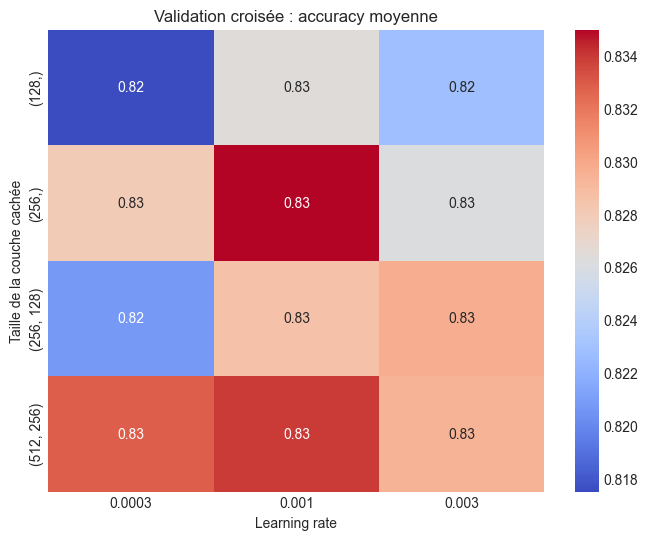

In [49]:
df = pd.DataFrame(results, columns=["hidden", "lr", "dropout", "mean_acc", "std_acc"])
df["hidden"] = df["hidden"].apply(lambda x: tuple(x)) # à retirer 
pivot = df.pivot_table(values="mean_acc", index="hidden", columns="lr")

plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, cmap=BACKGROUND_CMAP)
plt.title("Validation croisée : accuracy moyenne")
plt.ylabel("Taille de la couche cachée")
plt.xlabel("Learning rate")
plt.show()

On peut donc voir une légère progression des performances lorsque le nombre de couches du réseau augmente. De plus, on peut remarquer que les résultats sont quelque peu meilleurs pour un learning rate moyen $lr = 0,001$. 

A noter que même si une telle validation croisée reste informative dans ce cadre, elle gagnerait en pertinence en contrôlant davantage les sources de variance des résultats comme avec une stratification stricte des folds, une standardisation effectuée à l’intérieur de chaque split, et une répétition de la procédure pour lisser l’aléa. De cete manière, on obtiendrait une estimation plus fiable de l’effet réel des hyperparamètres, et on distinguerait plus nettement ce qui relève de la capacité du modèle de ce qui relève de l’instabilité de l’entraînement.

**Effet du dropout sur l'accuracy selon le learning rate et les couches du MLP**

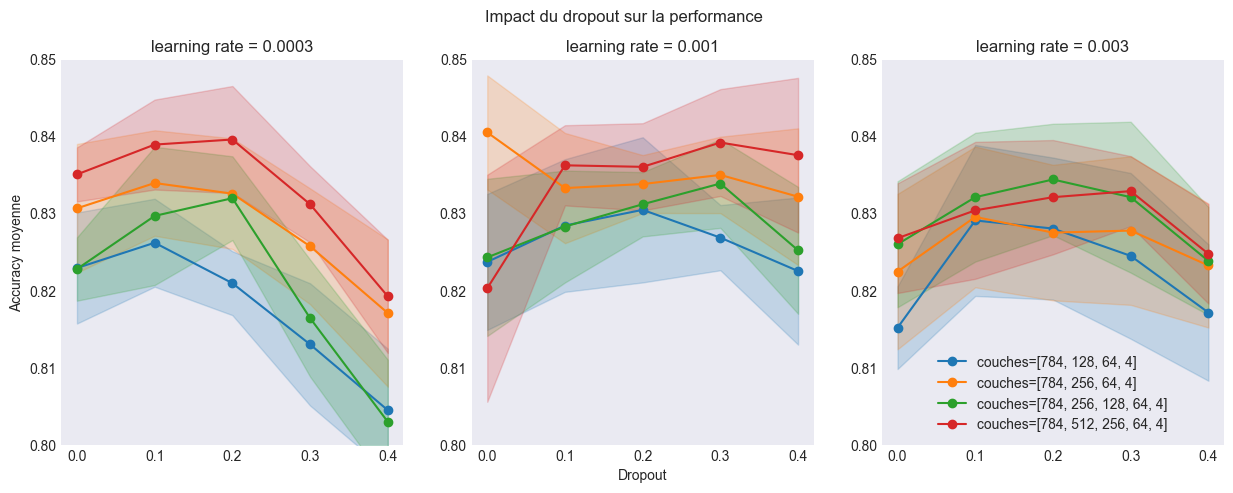

In [50]:
plt.figure(figsize=(15,5))

palette = sns.color_palette("tab10", len(hidden_sizes))
plt.subplot(1, 3, 1)
plt.ylabel("Accuracy moyenne")
plt.subplot(1, 3, 2)
plt.xlabel("Dropout")
for i, lr in enumerate([0.0003, 0.001, 0.003]):
    subset = df[df["lr"] == lr]
    plt.subplot(1, 3, i+1)
    for color, h in zip(palette, hidden_sizes):
        sub = subset[subset["hidden"] == h]
        plt.plot(sub["dropout"], sub["mean_acc"],  marker="o", label=f"couches={[784] + list(h) + [64, nb_classes]}", color=color)
        plt.fill_between(sub["dropout"], sub["mean_acc"] - sub["std_acc"], sub["mean_acc"] + sub["std_acc"], alpha=0.2, color=color)
    plt.title(f"learning rate = {lr}")    
    plt.grid()
    plt.ylim(0.8,0.85)
plt.legend()
plt.suptitle("Impact du dropout sur la performance")
plt.show()

#### III.3.9. Visualisation 

Image sauvegardée dans : ./img/animal/predict\MLP_predictions_80.png


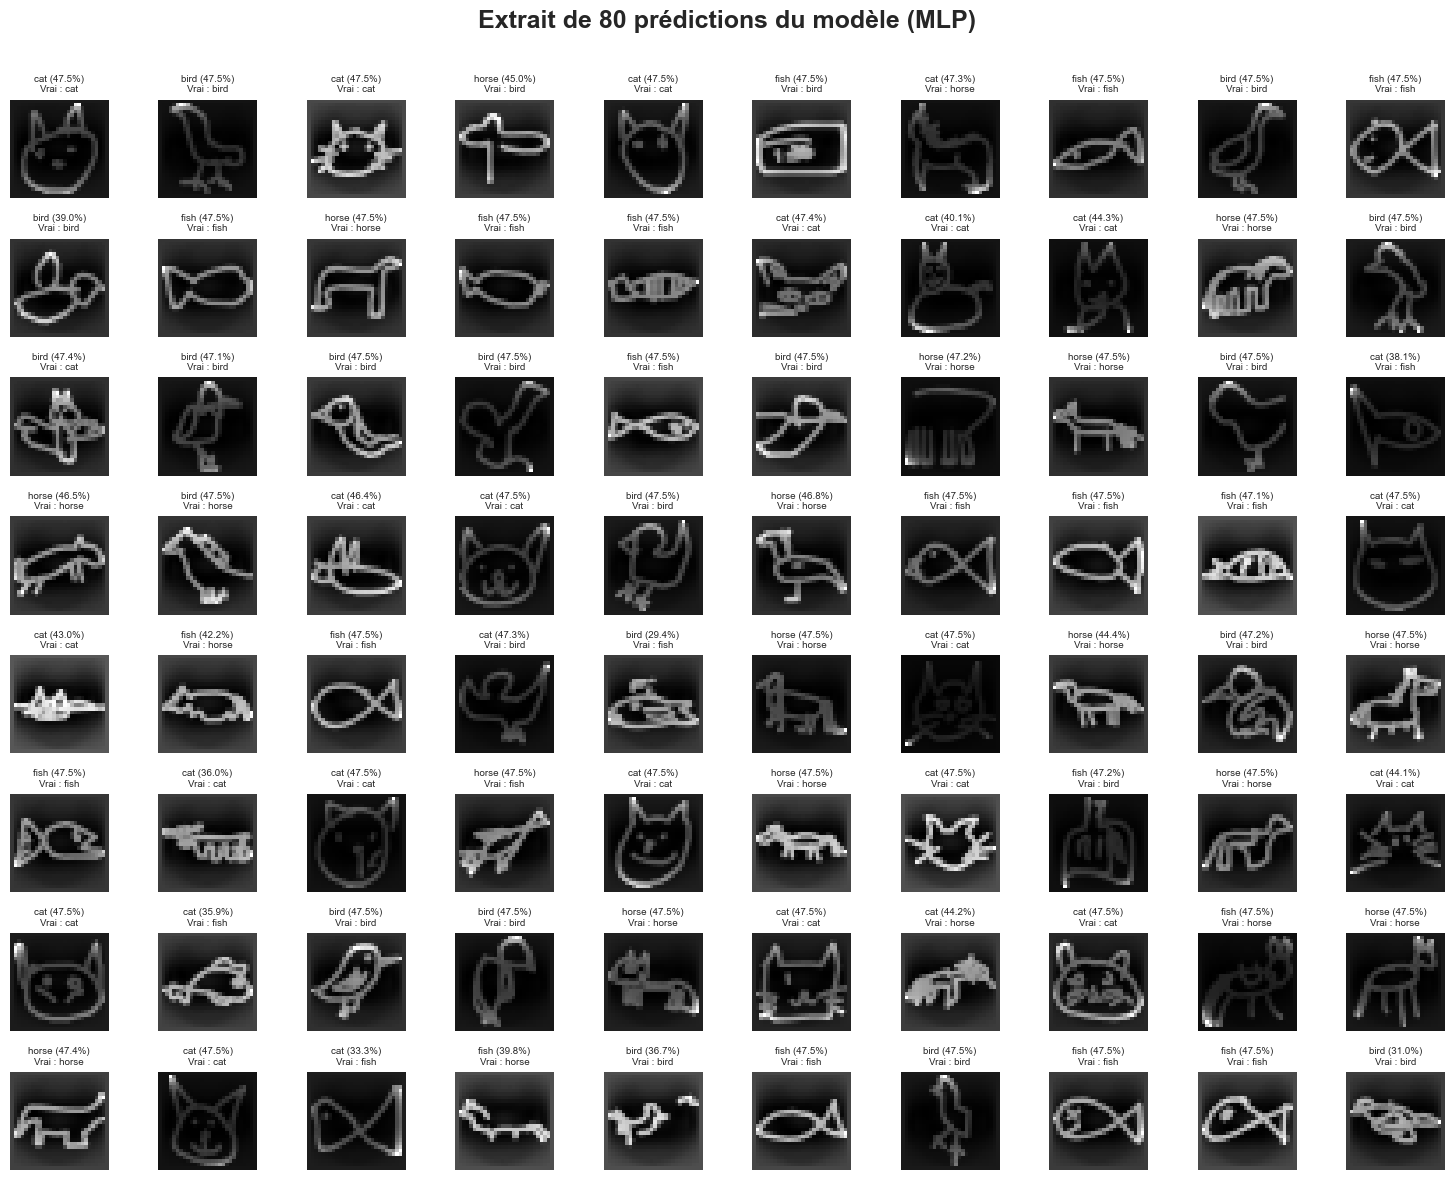

In [51]:
show_info.save_predictions_grid(X_test_scaled, y_test, best_preds_MLP, best_probs_MLP, animaux, rows=8, cols=10,
                                title="Extrait de 80 prédictions du modèle (MLP)",
                                save_name="MLP_predictions_80", save_dir="./img/animal/predict")


L'analyse des prédictions du modèle par rapport aux images du jeu de test, nous permet ainsi de voir que même si l'accuracy du modèle n'est pas parfaite, les erreurs qu'il réalise se concentre surtout autour d'images que même un agent humain aurait du mal à discriminer. Le plafonnement du modèle s'explique donc en partie par l'impureté des données traitées. Cependant, on peut également voir que les prédictions du modèle ne dépassent jamais une certitude de 50%, ce qui est plutôt mauvais si l'on venait à l'utiliser pour des applications réelles.

Finalement, on peut donc conclure que notre modèle MLP créé from scratch, et dont l'entrainement n'a pris que 2 minutes, arrive déjà bien mieux à apprendre des motifs et à généraliser sur le jeu de test que le modèle linéaire de régression logistique.

### III.4. Limites Persistantes du MLP

Malgré toute la richesse de ce formalisme, le MLP reste un modèle **entièrement connecté**, dans le sens où chaque neurone de la couche cachée reçoit des informations de *tous* les pixels de l'image, sans distinction spatiale. Ainsi, un pixel en haut à gauche et un autre en bas à droite auront exactement le même statut. Dans ce sens, le modèle ne peut pas exploiter le fait que les pixels voisins tendent à partager des informations visuelles.

De plus, le nombre de paramètres est en $\mathcal{O}(d \times h)$, soit environ 200 000 paramètres pour une image qui ne fait que $28 \times 28$ pixels avec $h = 256$ neurones. Pour des images de résolution réaliste ($256 \times 256$), ce MLP deviendrait computationnellement intraitable. 

Autrement dit, même si le MLP apprend mieux que la régression logistique grâce à sa non-linéarité, il n'exploite pas complètement la **structure spatiale locale** des images. C'est précisément cette idée qui va mener naturellement à l'introduction des convolutions.

## IV - Réseaux Convolutionnels (CNN)
---

Dans cette nouvelle section, nous allons donc découvrir les avantages de l'approche par **réseaux convolutionnels** (*Convolutional Neural Networks*, CNN), qui imposent une structure cohérente avec la manière dont les images sont organisées. 


### IV.1. Principe d'un CNN : exploiter la structure spatiale des images

#### IV.1.1. Hypothèse aux fondements des CNN : la Localité

En vision par ordinateur, on part de l'hypothèse qui affirme que les informations visuelles importantes apparaissent d’abord dans des zones locales de l’image. En d'autres termes, on suppose qu'un pixel est fortement corrélé à ses voisins proches puisque les motifs élémentaires comme les bords ou les coins émergent localement. Les formes plus complexes se construisent ensuite par composition de motifs simples. 

Les MLP ne tenaient pas compte de cette structure, car ils reliaient chaque pixel à tous les neurones sans distinction spatiale. Les CNN au contraire, obligent le modèle à se concentrer sur des régions locales en limitant les connexions d'un pixel à un voisinage local, puis accumulent les couches pour construire des représentations plus complexes.

#### IV.1.2. Opération centrale : Convolution Discrète 2D

L'opération centrale des CNN est la **convolution discrète 2D**. Lorsqu’on dispose d’une image $X \in \mathbb{R}^{H \times W}$ et d'un filtre (ou noyau) $K \in \mathbb{R}^{M \times N}$, on calcule une nouvelle image $Y$ en faisant glisser le filtre sur l’image et en combinant localement les valeurs de $X$ avec les poids de $K$. 

Chaque valeur $Y_{i,j}$ correspond donc à une somme pondérée des pixels situés dans la région de $X$, soit

$$(Y = X * K) \qquad \text{avec} \qquad Y_{i,j} = \sum_{u=0}^{M-1} \sum_{v=0}^{N-1} K_{u,v}\, X_{i+u,\, j+v}$$

A savoir que la convolution est un opérateur linéaire et invariant par translation, c'est-à-dire qu'il vérifie :
* **Linéarité** : $aX_1 + bX_2 \mapsto a(X_1 * K) + b(X_2 * K)$
* **Équivariance par translation** : $T_\tau(X) * K = T_\tau(X * K)$ où $T_\tau$ désigne une translation spatiale 

Dans ce sens, la convolution discrète 2D est un opérateur qui commute avec l’action du groupe des translations discrètes $\mathbb{Z}^2$. 

##### Exemple de convolution : détection de bord

Pour mieux comprendre le mécanisme de convolution, on peut s'appuyer sur l'exemple de détection des bords horizontaux ou verticaux d'une image à l'aide des filtres de Sobel.

Ces filtres sont définis par :

In [52]:
sobel_vertical = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

sobel_horizontal = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
], dtype=np.float32)

Si on applique chacun de ces filtres de convolution sur une image, on obtient :

Image sauvegardée dans : img/convolution\wall_e_edges.png


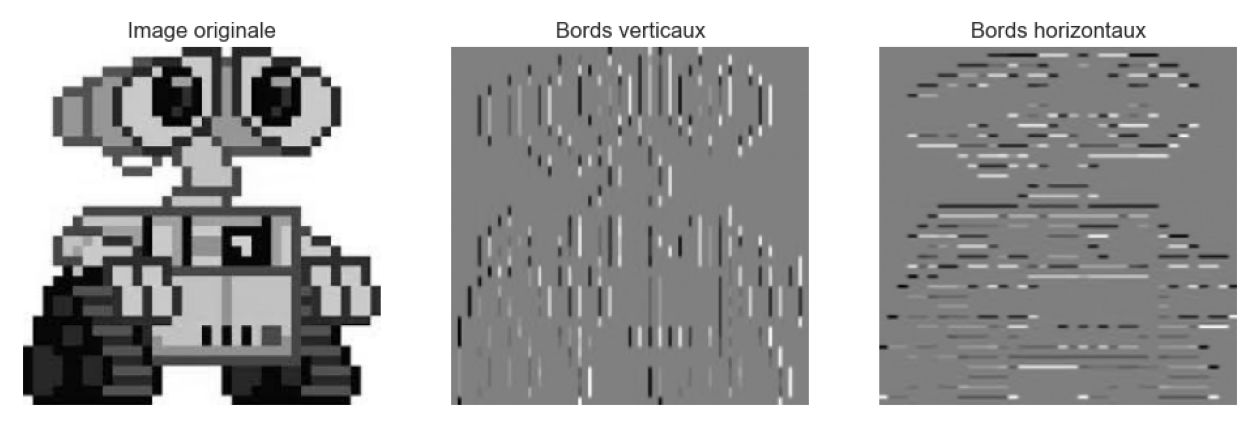

In [ ]:
img = show_info.open_img("img/convolution/wall-e.jpg")
h, w = img.shape
kH, kW = 3, 3

img_vertical_edges = np.zeros((h-2, w-2), dtype=np.float32)
img_horizontal_edges = np.zeros((h-2, w-2), dtype=np.float32)

for i in range(h-2):
    for j in range(w-2):
        patch = img[i:i+kH, j:j+kW]
        img_vertical_edges[i, j] = np.sum(patch * sobel_vertical)
        img_horizontal_edges[i, j] = np.sum(patch * sobel_horizontal)
        
show_info.save_merge_img([img, img_vertical_edges, img_horizontal_edges], 
                        ["Image originale", "Bords verticaux", "Bords horizontaux"],
                        save_dir="img/convolution", save_name="wall_e_edges")
show_info.show_img("img/convolution/wall_e_edges.png")

On peut donc voir que l'intensité des pixels est plus importante au niveau des bords à détecter.

#### IV.1.3. Cartes de Caractéristiques et Hiérarchie de Représentations

En effet, chaque filtre convolutionnel produit ce qu'on appelle une **carte de caractéristiques** (ou *feature map*) $Y$, c'est-à-dire une image dans laquelle chaque pixel indique **l’intensité du motif détecté par ce filtre** à cette position. 

Dans la première couche, les filtres apprennent généralement à repérer des éléments simples comme des *bords horizontaux ou verticaux*, des *coins* ou encore des *textures élémentaires*. Il ne s’agit pas encore de décisions finales, mais plutôt de ce qu'on appelle des **primitives visuelles**.

La véritable puissance des CNN apparaît en fait lorsque l’on **empile plusieurs couches convolutionnelles**. 

C'est pourquoi, de la même manière que pour les MLP, on applique une non‑linéarité $H = \text{ReLU}(X * K + b)$ après la première couche, puis on enchaîne avec une nouvelle couche de convolution qui opère sur les cartes produites précédemment. 

Les couches intermédiaires combinent alors ces primitives visuelles pour former des motifs plus complexes, comme des parties d’objets ou des contours fermés, tandis que les couches plus profondes capturent les structures de plus haut niveau. 

Cette hiérarchie de représentation permet ainsi, comme pour les MLP, l’approximation de fonctions de plus en plus complexes tout en respectant la structure spatiale de l'image.

#### IV.1.4. Paramètres du réseau : les coefficients des filtres

Dans un réseau CNN, ce sont en fait les **coefficients des filtres** qui représentent l'ensemble des paramètres du réseau (avec les biais). Concrètement, un CNN va donc chercher à ajuster les coefficients de ses filtres lors de l'entrainement, de sorte à ce que chaque filtre devienne un détecteur de motifs pertinent, et que l’ensemble du réseau produise des représentations de plus en plus discriminantes. 

Dans ce sens, pour construire un CNN pertinent, on fera en sorte que chaque filtre $K$ utilisé suive deux contraintes :
* il est de **petite taille** (typiquement $3 \times 3$ ou $5 \times 5$), ce qui oblige chaque neurone à ne prendre en compte qu’un voisinage local de l’image.  
* il est **appliqué de manière identique** à tous les emplacements de l’image (sans modifier ses poids - *weight sharing*).  

En effet, ce sont ces contraintes structurelles qui permettent au CNN de conserver ses deux propriétés fondamentales : la **localité** (petite taille) et l'**invariance par translation** (weight sharing).

Tout particulièrement, l'invariance par translation permise par le weight sharing garantit qu’une **même caractéristique est reconnue partout dans l’image**, ce qui permet par exemple d’identifier aussi bien un chat placé dans un coin qu’un chat situé au centre.

Par ailleurs, l'utilisation d'un petit filtre permet également de réduire le nombre de paramètres du modèle. Ainsi, pour une image de $28 \times 28$ pixels, on passe d'un modèle avec approximativement ($784 \times 256 \approx$) $200 000$ paramètres pour le MLP à $h = 256$ neurones cachés, à un modèle à ($3 \times 3 \times 24 =$) $216$ paramètres pour le CNN à $24$ filtres $3\times3$.

#### IV.1.5. Optimisations

##### IV.1.5.a. Padding et stride

Un premier problème que l'on rencontre [...]

Le padding et le stride servent à contrôler la manière dont un filtre parcourt une image lors d'une convolution.

* Le **padding** consiste à ajouter une **bordure de zéros** autour de l’image afin d’éviter une réduction trop rapide de sa taille et de permettre au filtre de traiter correctement les pixels situés en bordure. 
* Le **stride** correspond au **pas de déplacement** du filtre : un stride de 1 fait glisser le noyau pixel par pixel, tandis qu’un stride plus grand réduit la résolution de la sortie en sautant des positions. 

Ces deux paramètres déterminent directement la taille de la feature map produite et la quantité d’information spatiale conservée. 

On doit donc mettre à jour les dimensions $H\times W$ de l'image pour chaque couche :
$$H' = \frac{H + 2p - k}{s} + 1, \qquad W' = \frac{W + 2p - k}{s} + 1$$

Dans notre cas, considérant la petite taille des images, on utilisera seulement un padding de taille 1 pour éviter de perdre de l’information aux bords, et on gardera un stripe de 1.


In [54]:
def padding(X, pad):
    """Ajoute un padding de 0 autour de chaque image du batch X"""
    if pad == 0 or X.ndim != 4: 
        return X 
    else :
        return np.pad(X, ((0,0), (pad,pad), (pad,pad), (0,0)), mode='constant')


##### IV.1.5.b. Sous-Échantillonnage : Pooling

Les CNN incluent souvent des couches de **pooling**, une sorte de couche réseau qui sous-échantillonne et agrège l’information présente dans chaque petite région de l’image en un nombre réduit de valeurs. La variante la plus courante pour des petites images comme celles de notre dataset, est le *max‑pooling* $2 \times 2$, qui sélectionne la valeur maximale dans chaque fenêtre de taille $2 \times 2$ : 
$$Y_{i,j}=\underset{(u,v)\in \left\{ 0;1 \right\}}{\max}X_{2i+u;2j+v}$$

Ce mécanisme permet d'une part de **réduire la résolution spatiale**, ce qui diminue le nombre de paramètres dans les couches suivantes. D'autre part, il **renforce l'invariance aux petites translations**, puisqu'un léger déplacement d’un motif ne modifie pas la carte obtenue après max‑pooling. 

Le réseau apprend ainsi à se concentrer sur la présence d'un motif, plutôt que sur sa position exacte.

##### Exemple de max-pooling $2\times 2$

Image sauvegardée dans : img/convolution\wall_e_pooling2x2.png


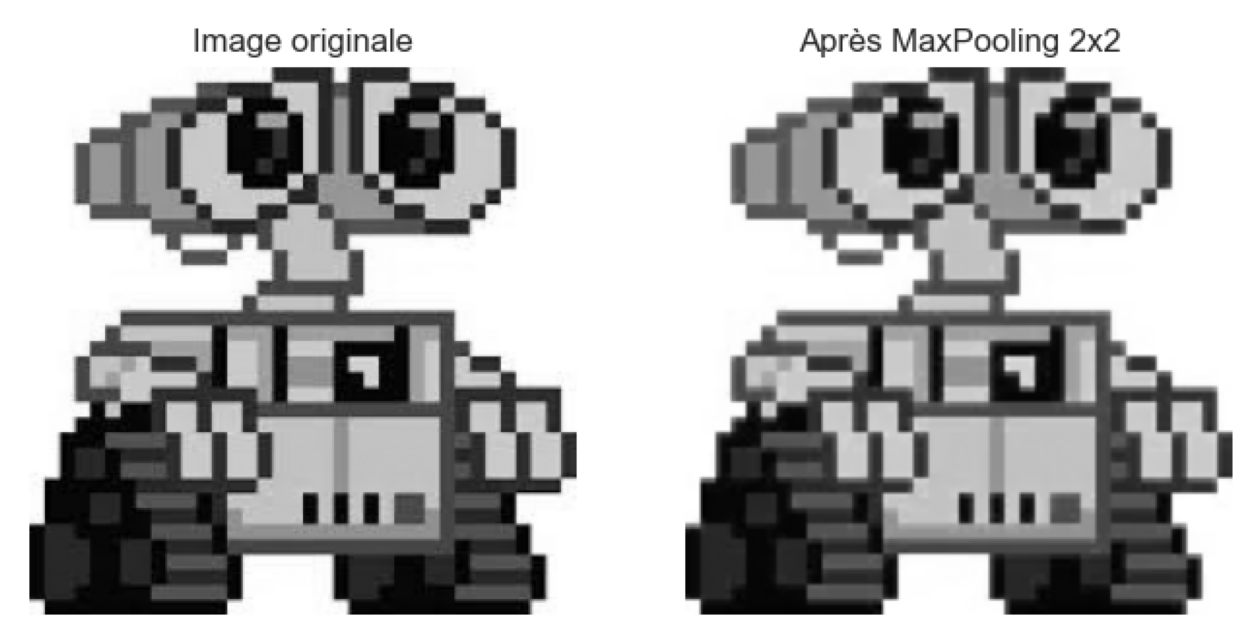

In [55]:
h_pool, w_pool = h // 2, w // 2
img_maxpooled = np.zeros((h_pool, w_pool), dtype=np.float32)
for i in range(h_pool):
    for j in range(w_pool):
        patch = img[i*2:(i+1)*2, j*2:(j+1)*2]
        img_maxpooled[i, j] = np.max(patch)

show_info.save_merge_img([img, img_maxpooled], 
                        ["Image originale", "Après MaxPooling 2x2"], 
                        save_dir="img/convolution", save_name="wall_e_pooling2x2")
show_info.show_img("img/convolution/wall_e_pooling2x2.png")



#### IV.1.6. Architecture Complète d'un CNN

Finalement, un CNN complet suit généralement une succession de blocs de type [*Convolution + ReLU + Pooling*] répétée plusieurs fois, avant d’**aplatir les cartes de caractéristiques** et de terminer par un **MLP** :
$$\left[ \text{Conv} + \text{ReLU}\, (\to \text{Pool}) \right]^{\text{nb}\_\text{couche}} \to \text{Flatten}\to \text{MLP}$$

On retrouve donc les couches entièrement connectées du MLP, mais uniquement à la fin, lorsque la structure spatiale a déjà été pleinement exploitée et transformée en représentations suffisamment discriminantes. 

#### IV.1.7. Format des données : le tenseur

Avant de formaliser la convolution, il est nécessaire de préciser comment les images et les filtres sont représentés en pratique. 

Pour manipuler des données dans un réseau de neuronne, les frameworks comme *PyTorch*, *TensorFlow* ou *JAX* utilise ce qu'on appelle des **tenseur** : des tableaux multidimensionnels capables de représenter aussi bien un scalaire qu’un vecteur, une matrice ou des structures plus complexes. 

En effet, les tenseurs présentent de nombreux avantages en terme de :
* **Efficacité** : les tenseurs permettent d’exécuter des opérations vectorisées massivement parallèles.
* **Généralité** : tous type de données peut être représentés comme un tenseur, ce qui unifie le traitement.
* **Traçabilité** : leur structure est pensée pour conserver l’historique des opérations, pour la rétropropagation.
* **Compatibilité matérielle** : les tenseurs sont optimisés pour exploiter les architectures modernes (CUDA, ROCm, XLA).

Dans le cas d'un CNN ce format de donnée est donc tout particulièrement adapté puisqu'il permet d’appliquer efficacement **tous les filtres sur toutes les images et tous les canaux en parallèle** (à l'aide de la bibliothèque NumPy).

Plus précisément, dans notre projet, on adoptera la convention *NHWC* pour les tenseurs d’images : 
$$X\in\mathbb{R}^{B\times H\times W\times C}$$

où $B$ représente la taille du batch, $H$ et $W$ la taille de l'image, et $C$ le nombre de canaux (par exemple $C=3$ pour le RGB)

***Note*** : *Le format utilisé pour le tenseur peut avoir un impact significatif sur l'accès à la mémoire et donc sur l'efficacité de calcul. Pour en savoir plus : [NHWC vs NCHW : A memory access perspective on GPUs - Medium](https://medium.com/@deepika_writes/nhwc-vs-nchw-a-memory-access-perspective-on-gpus-4e79bd3b1b54)*

Pour chaque couche de notre réseau, on doit également définir un **nombre donné $F$ de filtres**, tel que tous les filtres de la couche partagent les **mêmes caractéristiques** (taille, profondeur, padding, striping).

Ainsi, on stockera l'ensemble des filtres de dimension $k_H\times k_W$ d'une même couche, dans un autre tenseur :
$$W \in \mathbb{R}^{F \times C \times k_H \times k_W}$$

**Remarque** : On appelle $W$ le tenseur de filtre, pour faire un lien avec les poids du MLP. En effet, pour rappel, dans un CNN, ce sont les coefficients des filtres qui servent de paramètres.

L'homogénéité des caractéristiques des filtres d'une même couche permet de garantir que chaque filtre produit une carte de caractéristiques de même taille, ce qui permet de les empiler proprement en un tenseur de sortie après convolution : 
$$Z \in \mathbb{R}^{B \times H_{\text{out}} \times W_{\text{out}} \times F}$$

### IV.2. Implémentation d'un CNN from scratch en Numpy

Après avoir analysé les propriétés structurelles des réseaux convolutionnels, nous allons maintenant pouvoir implémenter un CNN from scratch en Numpy.

Encore une fois, l’objectif ici n’est pas de viser la performance du modèle (comme dans PyTorch ou TensorFlow), mais de comprendre la structure du pipeline forward/backward au complet.

#### IV.2.0. Architecture Complète d'un CNN

Pour rappel, un CNN complet suit généralement la structure :
$$\left[ \text{Conv} + \text{ReLU}\, (\to \text{Pool}) \right]^{\text{nb}\_\text{couche}} \to \text{Flatten}\to \text{MLP}$$

On divise donc la conception de notre modèle en 4 classes :
1. Classe `ConvLayer` ($\text{Conv} + \text{ReLU}$)
2. Classe `MaxPool` ($\text{Pool}$)
3. Classe `Flatten` ($\text{Flatten}$)
4. Classe `CNN` ($\text{CNN}$)

Dans un premier temps, avant d'implémenter les différentes classes, nous allons formaliser les fonctions de convolution avant et arrière, pour comprendre comment manipuler les filtres et comment calculer le gradient. 

#### IV.2.1. Fonctions de convolution

##### **Convolution à partir d'un tenseur**

Concrètement, la fonction de convolution calcule, pour chaque position $(h, w)$ et pour chaque filtre $f$ :
$$Z[:, h, w, f] \,=\, \sum_{i=0}^{k_H-1} \sum_{j=0}^{k_W-1} \sum_{c=0}^{C-1}
X_{\text{pad}}[:,\, h+i,\, w+j,\, c] \cdot W[f,\, c,\, i,\, j] \,+\, b[f] \in \mathbb{R}^{B}$$

On implémentera ce calcul de façon efficace à l'aide de la fonction NumPy : ```np.tensordot(patch, filter[f], axes=([1,2,3],[1,2,0]))```, où $\text{patch } = X_{\text{pad}}[:,\, h:h+kH,\, w:w+kW,\, :]$ représente un empilement de toutes les zones de pixels compris entre $(h,w)$ et $(h+kH, w+kW)$ pour chaque batch et chaque canaux.

Ainsi, la fonction de convolution d'une image s'écrit :

In [56]:
def conv_forward(x, W, b, stride, pad):
    '''
    x : (B, H_in, W_in, C_in)
    W : (F, C_in, kH, kW)
    b : (F,)
    '''
    B, H_in, W_in, _ = x.shape
    F, _, kH, kW     = W.shape

    x_pad = padding(x, pad)
    H_out = (H_in + 2 * pad - kH) // stride + 1
    W_out = (W_in + 2 * pad - kW) // stride + 1

    Z = np.zeros((B, H_out, W_out, F))

    for f in range(F):
        for h in range(H_out):
            for w in range(W_out):
                h_start = h * stride
                w_start = w * stride
                patch = x_pad[:, h_start:h_start+kH, w_start:w_start+kW, :]
                Z[:, h, w, f] = np.tensordot(patch, W[f], axes=([1,2,3],[1,2,0])) + b[f]

    return Z, x_pad

##### **Rétro-Propagation dans une couche convolutionnelle**

Conceptuellement, la rétro-propagation dans un CNN fonctionne exactement comme dans le MLP. En effet, la convolution est une **opération linéaire**, donc ses dérivées se déduisent pareillement de la dérivation d’un produit scalaire. 

La principale différence est que, puisqu'un même poids $W[f,c,i,j]$ (ou biais $b[f]$) est utilisé **à chaque position** où le filtre est appliqué, le gradient doit **accumuler les contributions de toutes ces positions**.

Dans ce sens, depuis les gradients en sortie pour chaque position $(h,w)$ : $dout[b,h,w,f]=\frac{\partial \mathcal{L}}{\partial Z[b,h,w,f]}$

Avec la sortie en position $(h,w)$ définie par :
$$\displaystyle Z[\,:\,, h, w, f] \,=\, \sum_{i=0}^{k_H-1} \sum_{j=0}^{k_W-1} \sum_{c=0}^{C-1}
X_{\text{pad}}[\,:\,,h+i, w+j, c] \times W[f, c, i, j] \,+\, b[f]$$

On trouve la dérivé de la sortie par rapport aux poids et aux biais :
$$\displaystyle \frac{\partial Z[b,h,w,f]}{\partial W[f,c,i,j]} = X_{\text{pad}}[b,h+i,w+j,c]
\quad \text{et} \quad
\displaystyle \frac{\partial Z[b,h,w,f]}{\partial b[f]} = 1$$

Ainsi, sachant que la règle de la chaine appliquée à l'ensemble des positions $(h,w)$ s'écrit : $$\displaystyle \frac{\partial \mathcal{L}}{\partial u} = \sum_{b,h,w}\frac{\partial L}{\partial Z[b,h,w,f]}\times\frac{\partial Z[b,h,w,f]}{\partial u}$$

On définit la dérivé de la fonction de perte par rapport aux poids et aux biais :
$$\begin{matrix}
\displaystyle \frac{\partial \mathcal{L}}{\partial W[f,c,i,j]}= \sum_{b,h,w} X_{\text{pad}}[b,h+i,w+j,c] \times dout[b,h,w,f] \\
\quad \text{et} \quad
\displaystyle \frac{\partial \mathcal{L}}{\partial b[f]} = \sum_{b,h,w} dout[b,h,w,f]
\end{matrix}$$

Autrement dit, puisqu'un même poids $W[f,c,i,j]$ contribue aux sorties sur toutes les positions $Z[b,h,w,f]$, sa contribution $\frac{\partial \mathcal{L}}{\partial W[f,c,i,j]}$ est la **somme de toutes les contributions locales** $\frac{\partial Z[b,h,w,f]}{\partial W[f,c,i,j]}$

**Remarque** : En python on simplifiera cette formule par `dW[f] += np.tensordot(dZ, patch, axes=([0],[0]))`

De la même manière, pour calculer le gradient par rapport à l’entrée $X_{\text{pad}}$, on additionne les contributions sur toutes les positions : 
$$\begin{matrix}\displaystyle 
\frac{\partial Z[b,h,w,f]}{\partial X_{\text{pad}}[b,h+i,w+j,c]} = W[f,c,i,j] \\ \\ \displaystyle 
\implies \frac{\partial \mathcal{L}}{\partial X_{\text{pad}}[b,h+i,w+j,c]} = \sum_{f,h,w} W[f,c,i,j] \times dout[b,h,w,f].
\end{matrix}$$

Finalement, la fonction de rétro-propagation dans une couche de convolution s'écrit :

In [57]:
def conv_backward(dout, x_pad, W, stride, pad):
    '''
    dout : (B, H_out, W_out, F)
    x_pad : (B, H_out, W_out, C_in)
    W : (F, C_in, kH, kW)
    '''
    B, H_out, W_out, F = dout.shape
    F, C_in, kH, kW    = W.shape

    dx_pad = np.zeros_like(x_pad)
    dW     = np.zeros_like(W)
    db     = np.zeros((F, 1))

    for f in range(F):
        db[f] = np.sum(dout[:, :, :, f])
        for h in range(H_out):
            for w in range(W_out):
                h_start, w_start = h * stride, w * stride
                patch = x_pad[:, h_start:h_start+kH, w_start:w_start+kW, :]
                dZ = dout[:, h, w, f]
                
                # tenserdot -> (kH, kW, C_in) / transpose -> (C_in, kH, kW)
                dW[f] += np.tensordot(dZ, patch, axes=([0],[0])).transpose(2,0,1) 
                
                # dZ[:, None, None, None] -> (B, 1, 1, 1)
                # W[f].transpose(1,2,0)[None] -> (1, kH, kW, C_in)
                dx_pad[:, h_start:h_start+kH, w_start:w_start+kW, :] += \
                    dZ[:, None, None, None] * W[f].transpose(1,2,0)[None]
                  
    # Retirer le padding
    dx = dx_pad[:, pad:-pad, pad:-pad, :] if pad > 0 else dx_pad

    return dx, dW, db

##### Implémentation de la classe 

Pour chaque couche on intialisera les poids $W\in\mathbb{R}^{F\times \text{fan}\_\text{in}}$ conformément à l'**initialisation de He**, tel que :
$$W\sim \mathcal{N}(0, \frac{2}{\text{fan}\_\text{in}})$$
où $F$ est le nombre de filtre et $\text{fan}\_\text{in}=C_\text{in}\times k \times k$ est le nombre total de valeurs d’entrée utilisées par un filtre, avec $k$ la taille du noyau et $C_\text{in}$ le nombre de canaux d'entrée.

In [58]:
class ConvLayer:
    def __init__(self, C_in, C_out, kernel_size, stride=1, pad=0):
        self.C_in = C_in
        self.C_out = C_out
        self.k = kernel_size
        self.stride = stride
        self.pad = pad

        # Initialisation He
        fan_in = C_in * kernel_size * kernel_size
        self.W = np.random.randn(C_out, C_in, kernel_size, kernel_size) * np.sqrt(2.0 / fan_in)
        self.b = np.zeros((C_out, 1))

        self.dW, self.db = None, None
        self.cache = None  # contiendra (x_pad, z)

    def forward(self, x):
        z, x_pad = conv_forward(x, self.W, self.b, self.stride, self.pad)
        A = relu(z)
        self.cache = (x_pad, z)
        return A

    def backward(self, dA):
        if self.cache is None:
            raise ValueError("forward doit être appelé avant backward.")
        
        x_pad, z = self.cache
        dz = dA * relu_deriv(z)
        dx, self.dW, self.db = conv_backward(dz, x_pad, self.W, self.stride, self.pad) 
        return dx


#### IV.2.2. Classe MaxPool

On définit donc les fonctions de max-pooling avant et arrière dans une classe dédiée.

Concrètement, cette classe ne contiendra que deux fonctions :
* `forward` : qui regroupe les pixels par blocs $p \times p$, puis sauvegarde un masque binaire indiquant la position du maximum : $Y = \max(X_{bloc})$
* `backward` : qui retourne le gradient venant de la couche suivante `dout` uniquement vers la position qui avait gagné le max (ie. celle où mask = 1) : $dX = mask \odot dout$

De cette manière, le masque généré par le max-pooling ne sort jamais de la classe. Et on garde une structure propre en terme d'encapsulation.

In [59]:
class MaxPool:
    def __init__(self, pool_size=2):
        self.pool_size = pool_size
        self.cache = None   # contiendra (x_reshaped, mask)

    def forward(self, x, training=False):
        """
        x : (B, H, W, C)
        Retourne : out (B, H_pool, W_pool, C)
        """
        B, H_in, W_in, C = x.shape
        p = self.pool_size

        H_pool = H_in // p
        W_pool = W_in // p

        x_reshaped = x[:, :H_pool*p, :W_pool*p, :] \
                        .reshape(B, H_pool, p, W_pool, p, C)
        out = x_reshaped.max(axis=(2, 4))
        mask = (x_reshaped == out[:, :, None, :, None, :])

        self.cache = (mask, x_reshaped.shape) # stockage pour backward

        return out

    def backward(self, dout):
        """
        dout : (B, H_pool, W_pool, C)
        Retourne : dx (B, H_in, W_in, C)
        """
        if self.cache is None:
            raise ValueError("forward doit être appelé avant backward.")
        
        mask, shape = self.cache
        _, H_pool, W_pool, C = dout.shape
        p = self.pool_size

        dx_reshaped = mask * dout[:, :, None, :, None, :]
        dx = dx_reshaped.reshape(shape[0], H_pool*p, W_pool*p, C)
        return dx

#### IV.2.3. Classe Flatten

Avant d'implémenter la classe CNN, on définit la dernière classe `Flatten`, qui ne fait qu'applatir les dimensions de l'images avec les canaux. 

In [60]:
class Flatten:
    def __init__(self):
        self.original_shape = None  # sera remplie au forward

    def forward(self, x):
        self.original_shape = x.shape  # (B, H, W, C)
        B = x.shape[0]
        return x.reshape(B, -1)

    def backward(self, dA_flat):
        return dA_flat.reshape(self.original_shape)

#### IV.2.4. Classe CNN

Pour finir, on implémente la classe `CNN` :

In [61]:
class CNN:
    def __init__(self, input_shape, conv_configs, mlp_dims, lr=0.001):
        """
        input_shape : (H, W, C)
        conv_configs : liste de dicts
            ex : [{"n_filters":8, "kernel_size":3, "pad":1, "pooling":2}, ...]
        mlp_dims : [flatten_dim, hidden1, ..., output_dim]
        """

        self.layers = []
        H, W, C = input_shape
        
        C_in = C
        reduction_factor = 1 
        for cfg in conv_configs:
            self.layers.append(
                ConvLayer(
                    C_in=C_in,
                    C_out=cfg["n_filters"],
                    kernel_size=cfg["kernel_size"],
                    stride=cfg.get("stride", 1),
                    pad=cfg.get("pad", 0)
                )
            )
            
            pool_size = cfg.get("pooling", 0)
            if pool_size != 0 :
                self.layers.append(MaxPool(pool_size))
                reduction_factor *= pool_size 
                
            C_in = cfg["n_filters"]

        self.layers.append(Flatten())
        
        dim_after_flatten = C_in * (H // reduction_factor) * (W // reduction_factor)
        mlp_dims = [dim_after_flatten] + mlp_dims
        self.layers.append(MLP(layer_dims=mlp_dims))

        # Paramètres pour Adam
        params = []
        for layer in reversed(self.layers): 
            if hasattr(layer, "W"):  # ConvLayer ou MLP
                if isinstance(layer.W, list):  # MLP
                    for W, b in zip(layer.W, layer.b):
                        params.append({"W": W, "b": b})
                else:  # ConvLayer
                    params.append({"W": layer.W, "b": layer.b})
            
        self.optimizer = Adam(params, lr=lr)

    def forward(self, X):
        A = X
        for layer in self.layers:
            # (toutes les layers ont une forward)
            A = layer.forward(A)
        return A

    def backward(self, Y):
        grads_W, grads_b = [], []

        # --- Backward du MLP ---
        grads_W, grads_b, dA = self.layers[-1].backward(Y)

        # --- Backward CNN ---
        for layer in reversed(self.layers[:-1]):
            dA = layer.backward(dA)
            if hasattr(layer, "W"): # ConvLayer
                grads_W.append(layer.dW)
                grads_b.append(layer.db)

        return grads_W, grads_b

    def train_batch(self, X, Y):
        P = self.forward(X)
        grads = self.backward(Y)
        self.optimizer.step(grads)
        return P


Concrètement, ce modèle repose sur l'architecture suivante :

#### IV.2.5. Diagramme UML du modèle CNN

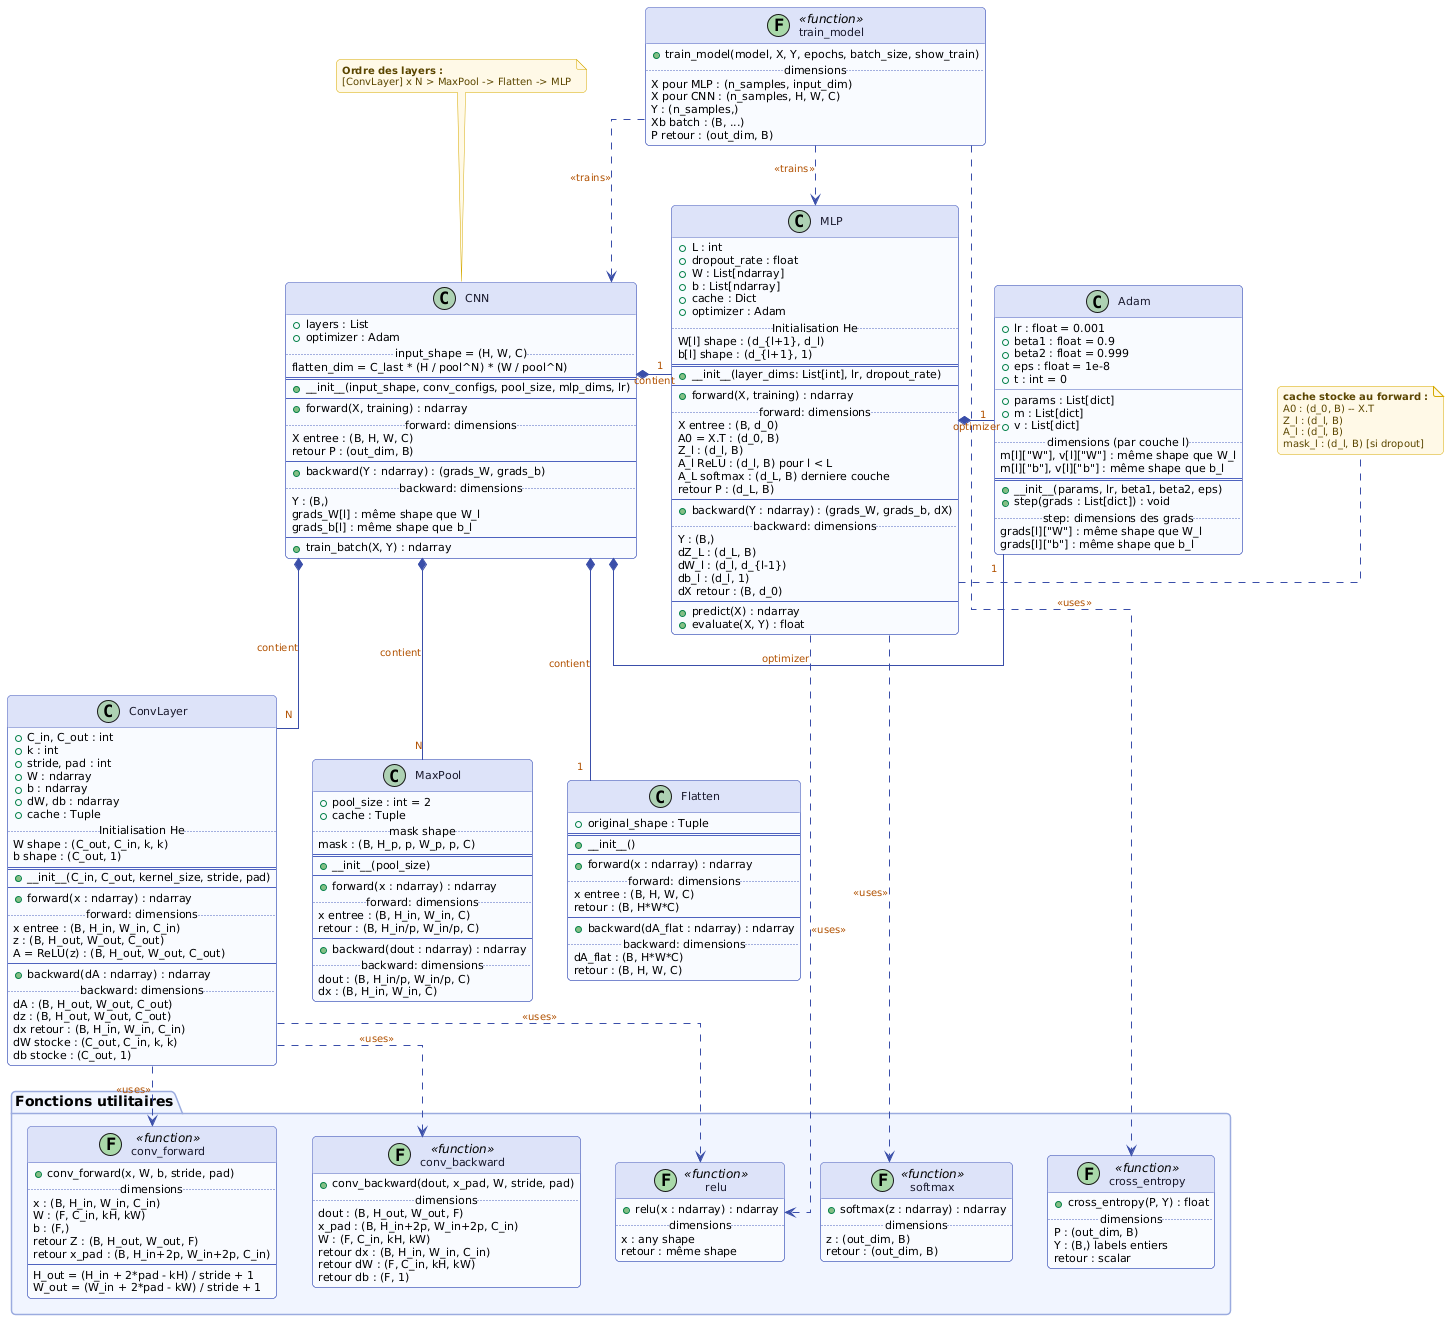

Finalement, on peut désormais entrainer notre modèle afin de comparer ses performances avec celles des autres modèles que nous avons précédemment entrainés.

#### IV.2.6. Entrainement et Analyse des résultats du CNN *from scratch*

In [62]:
model_CNN = CNN(input_shape=(28, 28, 1),
                conv_configs=[
                    {"n_filters":8, "kernel_size":3, 
                     "pad":1, "stride":1, "pooling":2}, 
                    {"n_filters":16, "kernel_size":3, 
                     "pad":1, "stride":1, "pooling":2}],
                mlp_dims=[64, 4],
                lr=0.001)

print(" ================= Architecture du modèle CNN ================= \n")
show_info.print_CNN_architecture(model_CNN) 
       
print("\n ================= Entraînement du modèle CNN... ================= \n")
train_model(model_CNN, X_train_scaled.reshape(-1, 28, 28, 1), y_train, epochs=20, batch_size=64, show_train=True)

preds, _ = predict(model_CNN, X_test_scaled.reshape(-1, 28, 28, 1))
accuracy_CNN = np.mean(preds == y_test)
print(f" ================= Accuracy du modèle CNN : {accuracy_CNN*100:.2f} % ================= ")

 ================= Architecture du modèle CNN ================= 

Layer 0: ConvLayer [8 filtres]  (k=3, stride=1, pad=1)
Layer 1: MaxPool
Layer 2: ConvLayer [16 filtres]  (k=3, stride=1, pad=1)
Layer 3: MaxPool
Layer 4: Flatten
Layer 5: MLP, Couches = [784, 64, 4]

 ================= Entraînement du modèle CNN... ================= 

Epoch   1/20  loss=0.7172  train_acc=73.48%
Epoch   2/20  loss=0.4424  train_acc=84.27%
Epoch   3/20  loss=0.3763  train_acc=86.80%
Epoch   4/20  loss=0.3325  train_acc=88.33%
Epoch   5/20  loss=0.3051  train_acc=89.20%
Epoch   6/20  loss=0.2709  train_acc=90.38%
Epoch   7/20  loss=0.2504  train_acc=91.03%
Epoch   8/20  loss=0.2309  train_acc=91.85%
Epoch   9/20  loss=0.2105  train_acc=92.36%
Epoch  10/20  loss=0.1927  train_acc=92.97%
Epoch  11/20  loss=0.1789  train_acc=93.44%
Epoch  12/20  loss=0.1597  train_acc=94.22%
Epoch  13/20  loss=0.1481  train_acc=94.54%
Epoch  14/20  loss=0.1386  train_acc=94.98%
Epoch  15/20  loss=0.1255  train_acc=95.37%
Epoch

L’accuracy obtenue de **88,88 %**, reflète donc une capacité encore meilleure du modèle à extraire des régularités pertinentes par rapport aux deux modèles abordés précédemment.

Pour autant, le modèle présente toujours un plateau de performance, ce qui renforce quelque peu notre intuition quant aux défauts stylistiques des données. Par ailleurs, il est possible que ce plafonement s'explique par l'**architecture volontairement réduite** du modèle. 

En effet, dans le cadre de ce notebook, nous avons favorsisé une architecture pédagogique, permettant de visualiser clairement les opérations effectuées, au détriment de certaines évidences conceptuelles pour une bonne efficacité computationnelle. 

Cependant, notre implémentation, même réduite, aura nécessité un temps d’entraînement d'environ **2h30** pour seulement 16 800 images en $28\times 28$. 

**Remarque** : il aurait été peut-être possible d'améliorer les performances du moèle en se tournant vers une bibliothèque compatible GPU comme CuPy, mais je ne peux vérifier cette hypothèse, ne disposant que d’un bon CPU.

C'est pourquoi, face aux limitations de notre modèle, on décide d'analyser les performances du CNN, en utilisant une architecture plus solide à l'aide du framework PyTorch..

**Note** : Pour supporter cette architecture plus importante, on imposera une normalisation `BatchNorm` ($\hat{x}=\frac{x-\mu_B}{\sqrt{\sigma_B^2+\varepsilon}}$) après la convolution, afin de réduire le phénomène de *covariate shift interne*, c’est‑à‑dire le fait que les distributions d’entrée des couches de convolution dérive progressivement. Autrement dit, on évitera que chaque couche apprenne une fonction de perte à partir de distributions différentes à chaque itération, afin de faciliter l’optimisation et d'améliorer la fiabilité des gradients. 

#### IV.2.9. Implémentation d'un CNN avec PyTorch


In [73]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

class SimpleCNN(nn.Module):
    def __init__(self, input_shape, conv_configs, mlp_dims, lr=0.001, dropouts=0.2):
        '''
        input_shape : (C, H, W)
        conv_config : [{"n_filters":8, "kernel_size":3, "pad":1, "stride":1, "pool":2}, ...]
        mlp_dims : [hidden1, ..., output_dim]
        '''

        super().__init__()
        self.lr = lr
        C_in, H, W = input_shape
        C_in_0 = C_in

        # Couche de Convolution
        layers = []
        for cfg in conv_configs:
            layers.append(
                nn.Conv2d(
                    in_channels=C_in,
                    out_channels=cfg["n_filters"],
                    kernel_size=cfg["kernel_size"],
                    stride=cfg.get("stride", 1),
                    padding=cfg.get("pad", 0)
                )
            )
            C_in = cfg["n_filters"]
            
            layers.append(nn.BatchNorm2d(C_in))
            layers.append(nn.ReLU())

            pool_size = cfg.get("pool", 0)
            if pool_size > 1 :
                layers.append(nn.MaxPool2d(pool_size))

        self.features = nn.Sequential(*layers)

        # Calcul automatique de la taille de sortie (dummy)
        with torch.no_grad():
            dummy = torch.zeros(1, C_in_0, H, W)
            out = self.features(dummy)
            flat_dim = out.numel()

        # Couche : Flatten + MLP
        mlp_layers = []
        in_dim = flat_dim

        for dim in mlp_dims[:-1]:
            mlp_layers.append(nn.Linear(in_dim, dim))
            mlp_layers.append(nn.ReLU())
            mlp_layers.append(nn.Dropout(dropouts))
            in_dim = dim

        # Dernière couche (sortie)
        mlp_layers.append(nn.Linear(in_dim, mlp_dims[-1]))

        self.classifier = nn.Sequential(nn.Flatten(), *mlp_layers)

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x
    

# Redéfinition des fonctions de prédiction et d'entraînement pour les modèles PyTorch
def predict(model, x):
    model.eval()
    x = torch.tensor(x, dtype=torch.float32)
    # on désactive le calcul du gradient avec "no_grad()"
    with torch.no_grad():
        logits = model.forward(x)
        all_probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(logits, dim=1)
            
    return preds.numpy(), all_probs.numpy()
    

def train_model(model, X_train, y_train, epochs=20,
                batch_size=64, lr=1e-3, show_train=True):
    device = torch.device("cpu")
    model.to(device)

    X_train = torch.tensor(X_train, dtype=torch.float32)
    y_train = torch.tensor(y_train, dtype=torch.long)

    dataset = TensorDataset(X_train, y_train)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            
        if show_train :
            print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss/len(loader):.4f}")


#### IV.2.10. Entrainement et Validation croisée du modèle

##### IV.2.10.a. Entrainement du modèle

In [64]:
model_TorchCNN = SimpleCNN(
                    input_shape=(1, 28, 28),
                    conv_configs=[
                        {"n_filters":8, "kernel_size":3, "pad":1, "stride":1, "pool":0}, 
                        {"n_filters":16, "kernel_size":3, "pad":1, "stride":1, "pool":2}],
                    mlp_dims=[64, 4], 
                    lr=0.001, dropouts=0.2
                )

print(" ================= Architecture du modèle CNN (PyTorch) ================= \n")
show_info.print_CNNTorch_architecture(model_TorchCNN)

print("\n ================= Entraînement du modèle CNN (PyTorch)... ================= \n")
train_model(model_TorchCNN, X_train_scaled.reshape(-1, 1, 28, 28), y_train, epochs=15)

accuracy_torch = evaluate(model_TorchCNN, X_test_scaled.reshape(-1, 1, 28, 28), y_test)
print(f"\n ================= Accuracy du modèle CNN PyTorch : {accuracy_torch*100:.2f} % ================= ")

 ================= Architecture du modèle CNN (PyTorch) ================= 

Layer 0 : Conv2d [8 filtres]  (k=3, stride=1, pad=1)
Layer 1 : BatchNorm2d
Layer 2 : ReLU
Layer 3 : Conv2d [16 filtres]  (k=3, stride=1, pad=1)
Layer 4 : BatchNorm2d
Layer 5 : ReLU
Layer 6 : MaxPool2d
Layer 7 : Flatten
Layer 8 : MLP, Couches = [64, 4, 4]

 ================= Entraînement du modèle CNN (PyTorch)... ================= 

Epoch 1/15 - Loss: 0.5439
Epoch 2/15 - Loss: 0.3636
Epoch 3/15 - Loss: 0.3066
Epoch 4/15 - Loss: 0.2733
Epoch 5/15 - Loss: 0.2424
Epoch 6/15 - Loss: 0.2193
Epoch 7/15 - Loss: 0.1967
Epoch 8/15 - Loss: 0.1740
Epoch 9/15 - Loss: 0.1583
Epoch 10/15 - Loss: 0.1374
Epoch 11/15 - Loss: 0.1243
Epoch 12/15 - Loss: 0.1176
Epoch 13/15 - Loss: 0.1033
Epoch 14/15 - Loss: 0.0987
Epoch 15/15 - Loss: 0.0876

 ================= Accuracy du modèle CNN PyTorch : 88.60 % ================= 


##### IV.2.10.b. Validation croisée

In [89]:
# Grille d’hyperparamètres
conv_configs_grid = [
    [{"n_filters":8, "kernel_size":3, "pad":1, "stride":1},
    {"n_filters":16, "kernel_size":3, "pad":1, "stride":1, "pool":2}],
    
    [{"n_filters":16, "kernel_size":3, "pad":1, "stride":1},
    {"n_filters":32, "kernel_size":3, "pad":1, "stride":1, "pool":2}],
    
    [{"n_filters":8, "kernel_size":3, "pad":1, "stride":1},
    {"n_filters":16, "kernel_size":3, "pad":1, "stride":1},
    {"n_filters":32, "kernel_size":3, "pad":1, "stride":1, "pool":2}],
    
    [{"n_filters":8, "kernel_size":3, "pad":1, "stride":1},
    {"n_filters":16, "kernel_size":3, "pad":1, "stride":1},
    {"n_filters":32, "kernel_size":2, "pad":1, "stride":1, "pool":2}],
    
    [{"n_filters":16, "kernel_size":3, "pad":1, "stride":1},
    {"n_filters":32, "kernel_size":3, "pad":1, "stride":1},
    {"n_filters":64, "kernel_size":3, "pad":1, "stride":1, "pool":2}]
]

mlp_dims_grid = [(), (128,), (256, 128)]

best_acc = -1
best_params = {}
results = []

import time
for conv_cfg in conv_configs_grid:
    for mlp_dims in mlp_dims_grid:

        mlp_dims_full = list(mlp_dims) + [64, 4]
        params = {"input_shape": (1, 28, 28),
                  "conv_configs": conv_cfg,
                  "mlp_dims": mlp_dims_full
                  }
                
        filters = [(cfg["n_filters"], cfg["kernel_size"]) for cfg in conv_cfg]
        print(f"- Test CNN : conv={filters}, mlp={mlp_dims_full}...", end=" ")
        start = time.time()
        mean_acc, std_acc = cross_val_score_model(
            SimpleCNN, params, X_train.reshape(-1, 1, 28, 28), y_train,
            epochs=10, batch_size=64, K=5
        )
        end = time.time()
        duree = (end-start)/60

        results.append((conv_cfg, mlp_dims_full, duree, mean_acc, std_acc))
        print(f"acc={mean_acc:.4f} +/- {std_acc:.4f} ({duree:.1f} min)")
                
        if mean_acc > best_acc:
            best_acc = mean_acc
            best_params = params


- Test CNN : conv=[(8, 3), (16, 3)], mlp=[64, 4]... acc=0.8966 +/- 0.0080 (3.1 min)
- Test CNN : conv=[(8, 3), (16, 3)], mlp=[128, 64, 4]... acc=0.8980 +/- 0.0060 (4.3 min)
- Test CNN : conv=[(8, 3), (16, 3)], mlp=[256, 128, 64, 4]... acc=0.8974 +/- 0.0067 (4.5 min)
- Test CNN : conv=[(16, 3), (32, 3)], mlp=[64, 4]... acc=0.8951 +/- 0.0044 (7.2 min)
- Test CNN : conv=[(16, 3), (32, 3)], mlp=[128, 64, 4]... acc=0.9000 +/- 0.0073 (8.7 min)
- Test CNN : conv=[(16, 3), (32, 3)], mlp=[256, 128, 64, 4]... acc=0.9024 +/- 0.0032 (10.2 min)
- Test CNN : conv=[(8, 3), (16, 3), (32, 3)], mlp=[64, 4]... acc=0.8980 +/- 0.0079 (11.0 min)
- Test CNN : conv=[(8, 3), (16, 3), (32, 3)], mlp=[128, 64, 4]... acc=0.9011 +/- 0.0065 (10.9 min)
- Test CNN : conv=[(8, 3), (16, 3), (32, 3)], mlp=[256, 128, 64, 4]... acc=0.8999 +/- 0.0052 (12.1 min)
- Test CNN : conv=[(8, 3), (16, 3), (32, 2)], mlp=[64, 4]... acc=0.8987 +/- 0.0048 (9.0 min)
- Test CNN : conv=[(8, 3), (16, 3), (32, 2)], mlp=[128, 64, 4]... acc=0.

In [90]:
print("\n ------------------ Meilleurs paramètres : ------------------")
print(f"  - Couches de convolution :", end=" ")
for config in best_params["conv_configs"] :
    n, s = config["n_filters"], config["kernel_size"]
    print(f"{n} filtres ({s}x{s}),", end=" ")
print(f"\n  - Couches du MLP : {best_params["mlp_dims"]}")
print(f"\n ================= Accuracy du meilleur modèle CNN : {best_acc*100:.2f} % ================= \n")


 ------------------ Meilleurs paramètres : ------------------
  - Couches de convolution : 16 filtres (3x3), 32 filtres (3x3), 64 filtres (3x3), 
  - Couches du MLP : [256, 128, 64, 4]

 ================= Accuracy du meilleur modèle CNN : 90.56 % ================= 



**Heatmap de l'accuracy mettant en corrélation les couches de convolution et celles du MLP**

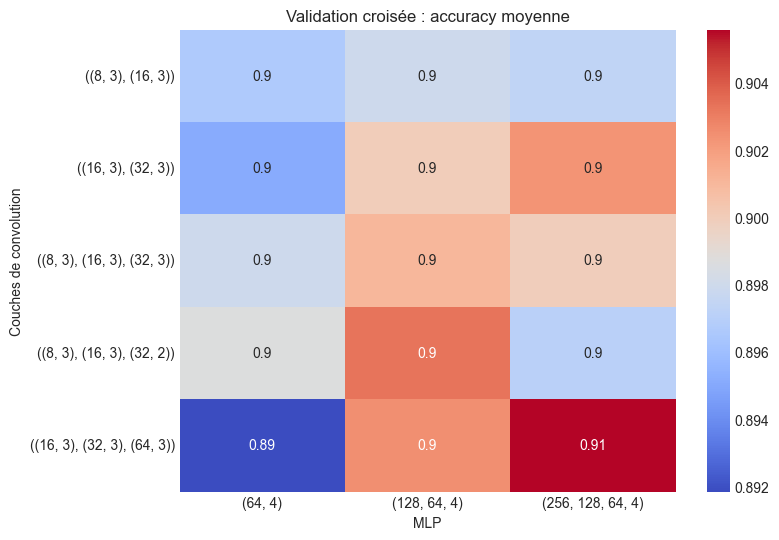

In [92]:
df = pd.DataFrame(results, columns=["conv_cfg", "mlp_dims", "time", "mean_acc", "std_acc"])
df["conv_cfg"] = df["conv_cfg"].apply(
    lambda conv_list: tuple((c["n_filters"], c["kernel_size"]) for c in conv_list)
)
df["mlp_dims"] = df["mlp_dims"].apply(tuple)
pivot = df.pivot_table(values="mean_acc", index="conv_cfg", columns="mlp_dims", sort=False)

plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, cmap=BACKGROUND_CMAP)
plt.title("Validation croisée : accuracy moyenne")
plt.ylabel("Couches de convolution")
plt.xlabel("MLP")
plt.show()

**Mise en comparaison du gain en accuracy avec le temps d'entrainement**

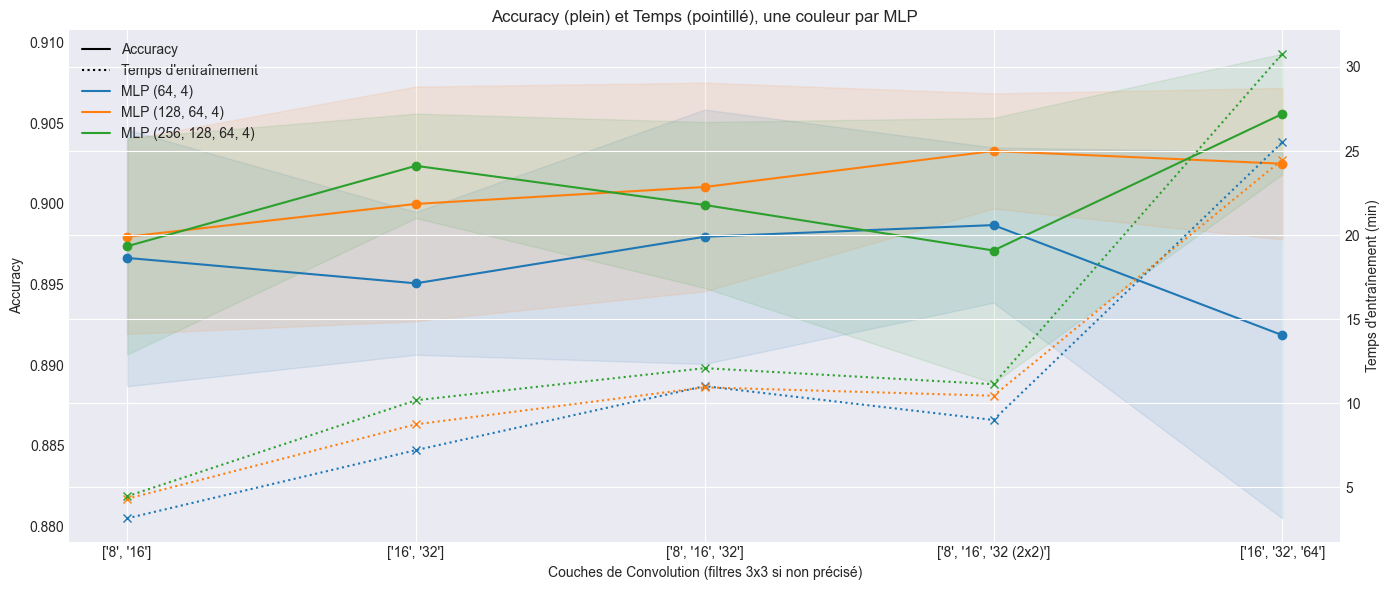

In [96]:
from matplotlib.lines import Line2D

# Axe X numérique
conv_keys = df["conv_cfg"].unique()
x = np.arange(len(conv_keys))

xlabels = [[f"{filter[0]} ({filter[1]}x{filter[1]})" if filter[1]!=3 
            else f"{filter[0]}" for filter in ck] for ck in conv_keys]
mlp_keys = df["mlp_dims"].unique()
palette = dict(zip(mlp_keys, sns.color_palette("tab10", len(mlp_keys))))

fig, ax = plt.subplots(figsize=(14,6))
ax2 = ax.twinx()
legend_elements = [
    Line2D([0], [0], color="black", linestyle="-", label="Accuracy"),
    Line2D([0], [0], color="black", linestyle=":", label="Temps d'entraînement")
]

for mlp in mlp_keys:
    sub_mlp = df[df["mlp_dims"] == mlp]
    color = palette[mlp]
    legend_elements.append(Line2D([0], [0], color=color, label=f"MLP {mlp}"))

    acc_values = [sub_mlp[sub_mlp["conv_cfg"] == ck]["mean_acc"].mean() for ck in conv_keys]
    std_values = [sub_mlp[sub_mlp["conv_cfg"] == ck]["std_acc"].mean() for ck in conv_keys]
    time_values = [sub_mlp[sub_mlp["conv_cfg"] == ck]["time"].mean() for ck in conv_keys]

    ax.plot(x, acc_values, linestyle="-", marker="o", color=color, label=f"MLP {mlp}")
    ax.fill_between(x,
                    np.array(acc_values) - np.array(std_values),
                    np.array(acc_values) + np.array(std_values),
                    color=color, alpha=0.1, 
                    )
    ax2.plot(x, time_values, linestyle=":", marker="x", color=color)

ax.set_xticks(x)
ax.set_xticklabels(xlabels)
ax.set_xlabel("Couches de Convolution (filtres 3x3 si non précisé)")
ax.set_ylabel("Accuracy")
ax2.set_ylabel("Temps d'entraînement (min)")
ax.set_title("Accuracy (plein) et Temps (pointillé), une couleur par MLP")
ax.grid(axis="y")
ax.legend(handles=legend_elements, loc="upper left")
plt.tight_layout()
plt.show()


A noter que cette expérimentation n’est qu’un échantillon de ce que l’on pourrait attendre de l’entrainement d’un modèle selon sa configuration en termes de couches de convolution et de couches non linéaires. Un test standardisé aurait nécessité d’évaluer ces architectures sur un ensemble beaucoup plus large de jeux de données, et de répéter les mesures dans des conditions bien mieux contrôlées.

On peut néanmoins remarquer que l'accuracy des modèles est plutôt similaire, même en adaptant les différentes couches. On peut tout de même souligner le niveau de performance du modèle aves le plus petit nombre de filtres par rapport aux autres, sachant qu'il a nécessité deux fois moins de temps d'entrainement. On remarquera également qu'un modèle très lourd demande bien plus de temps d'entrainement (sûrement dû à des limitations en RAM) mais ne semble pas vraiment améliorer les performances du modèle.

**Evaluation et sauvegarde du meilleur modèle**

In [86]:
import json

best_model_CNN = SimpleCNN(**best_params)
train_model(best_model_CNN, X_train.reshape(-1, 1, 28, 28), y_train, epochs=20, batch_size=64, show_train=False)

best_preds_CNN, best_probs_CNN = predict(best_model_CNN, X_test.reshape(-1, 1, 28, 28))
best_accuracy_CNN = np.mean(best_preds_CNN == y_test)
print(f"\n ================= Accuracy du meilleur modèle CNN : {best_accuracy_CNN*100:.2f} % ================= \n")

# Sauvegarde du modèle et des hyperparamètres
SAVE_DIR    = "./models_checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)
path_model = os.path.join(SAVE_DIR, "best_model_CNN.pth")
path_param = os.path.join(SAVE_DIR, "best_params.json")

torch.save(best_model_CNN.state_dict(), path_model)
with open(path_param, "w") as f:
    json.dump(best_params, f)

print(f" -> Modèle sauvegardé dans {path_model}")
print(f" -> Hyperparamètres sauvegardés dans {path_param}")



 ================= Accuracy du meilleur modèle CNN : 90.97 % ================= 

 -> Modèle sauvegardé dans ./models_checkpoints\best_model_CNN.pth
 -> Hyperparamètres sauvegardés dans ./models_checkpoints\best_params.json


#### IV.2.11. Performances finales du CNN

Image sauvegardée dans : ./img/animal/predict\TorchCNN_predictions_80.png


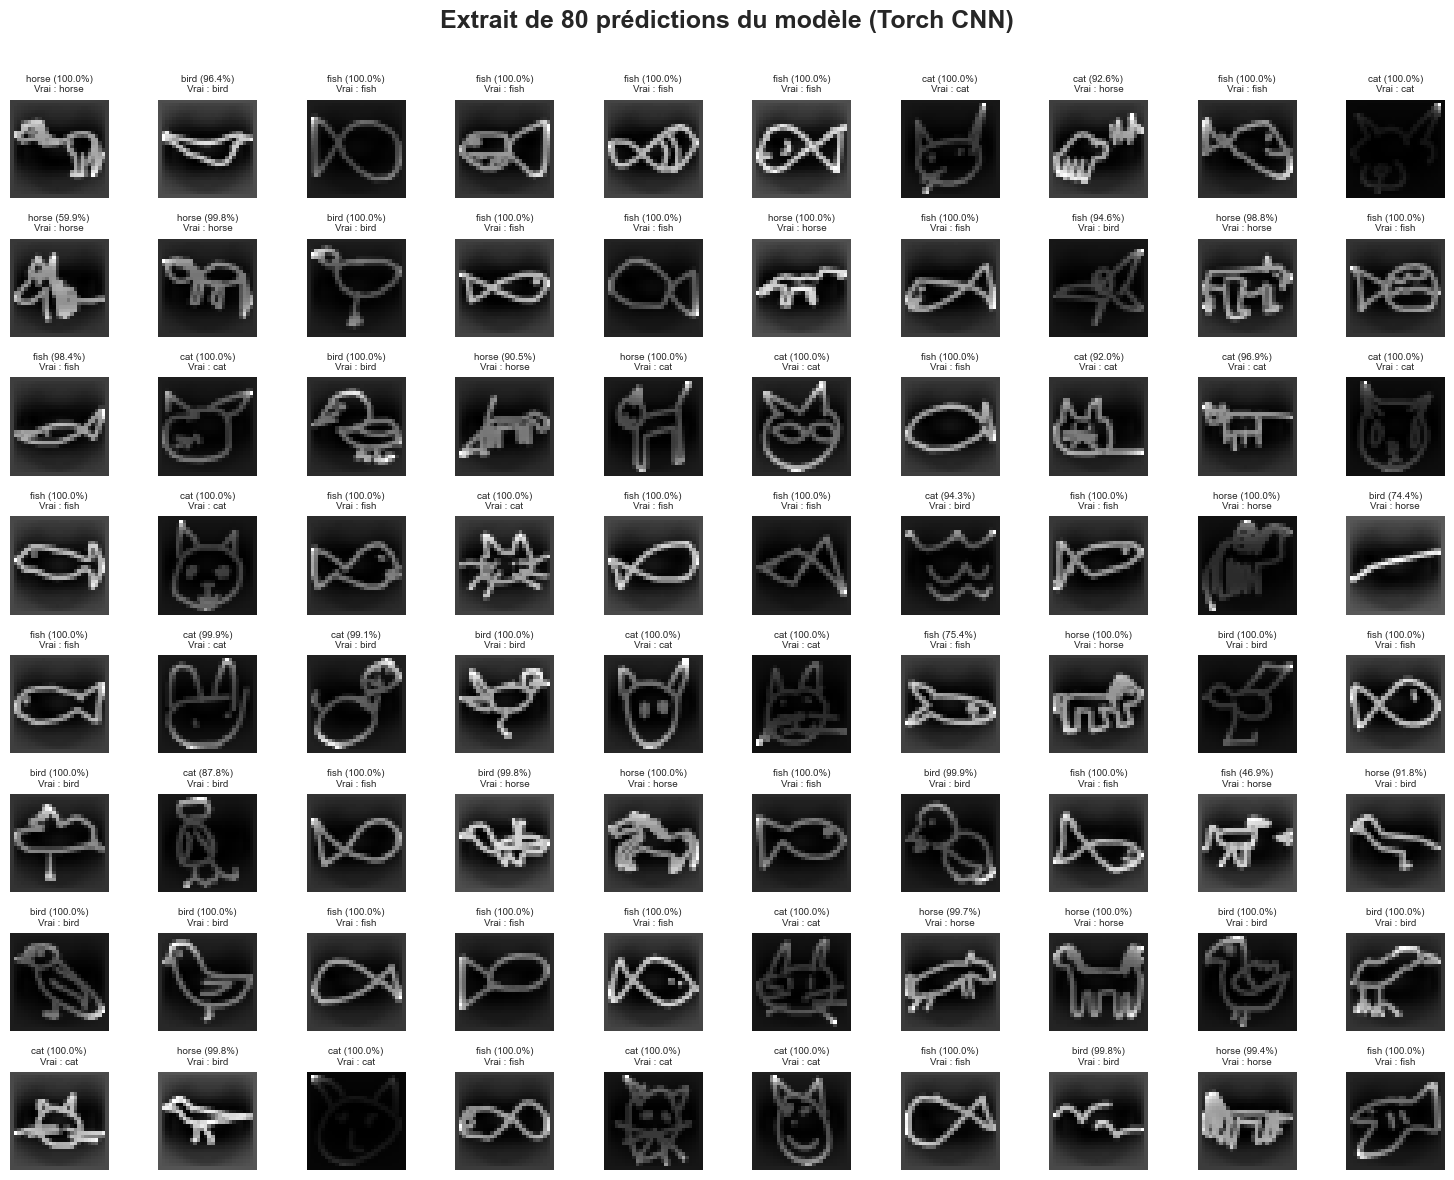

In [87]:
show_info.save_predictions_grid(X_test_scaled, y_test, best_preds_CNN, best_probs_CNN.T, animaux, rows=8, cols=10,
                                title="Extrait de 80 prédictions du modèle (Torch CNN)",
                                save_name="TorchCNN_predictions_80", save_dir="./img/animal/predict")

On obtient finalement un réseau capable de discriminer avec une forte confiance les doodles de notre dataset. 

En effet, les réseaux CNN sont dans la plupart des cas les modèles les plus adaptés pour de la reconnaissance d'images. De par leur structure en **couches de convolution** qui permet de détecter d’abord des motifs locaux puis de les combiner en formes plus complexes, tout en restant robustes aux translations, les CNN demeurent les modèles les plus performants avec un nombre de paramètres bien plus réduit.

Cette grande efficacité résulte en fait d’une histoire progressive qui a construit la méthode que l'on connait aujourd'hui, structurée par plusieurs décennies de travaux en vision artificielle et en apprentissage automatique.

### IV.2. Histoire et évolution des réseaux convolutionnels 

*Informations sur l'évolution des réseaux convolutionnels provenant du site [Read Medium](https://readmedium.com/the-evolution-of-convolutional-neural-networks-from-lenet-to-convnext-0b1c37ccb52f) et de la page Wikipedia [Convolutional Neural Network](https://en.wikipedia.org/wiki/Convolutional_neural_network)*

#### IV.2.1. Origines neurophysiologiques et premières architectures (1980)

Les premières idées à l’origine des réseaux convolutionnels remontent aux travaux des neurophysiologistes *Hubel* et *Wiesel* en 1962 sur l’organisation du cortex visuel des mammifères, qui ont démontré que les neurones ne perçoivent pas l'image de manière globale, mais réagissent à des stimuli dans des zones très limitées, appelées champs récepteurs. Les auteurs ont identifié ce qu'ils appellent des 'cellules simples' (détectant des bords) et des 'cellules complexes' (intégrant l'information spatiale), mettant en évidence une hiérarchie de neurones sensibles à des motifs locaux puis à des combinaisons plus complexes. 

En s'inspirant de ces travaux, Fukushima propose en 1980, le **Neocognitron** [[15]](#ref15), une architecture hiérarchique intégrant des champs récepteurs locaux et des mécanismes d’invariance aux translations. Même si ce modèle était encore dépourvu d’apprentissage par gradient, il a permis d'introduire les principes fondamentaux de la convolution et du sous‑échantillonnage, qui deviendront centraux dans les CNN modernes. 

#### IV.2.2. Introduction de la rétropropagation dans les architectures convolutionnelles (fin des années 1980)

C'est à la fin des années 1980, après près de 10 ans d'expérimentation, que la rétropropagation, déjà utilisée dans les réseaux multicouches, est appliquée à des architectures à poids partagés. Les travaux de Denker, LeCun et al. montrent ainsi, dans leurs travaux consacrés à la reconnaissance de Zip Code manuscrit [[16]](#ref16), que les filtres convolutionnels peuvent être **appris automatiquement** à partir des données, ancrant les travaux de Fukushima dans un cadre supervisé et optimisable. Cette période établit alors les bases des CNN entraînables, en démontrant la pertinence du partage de poids et de l’apprentissage hiérarchique pour la reconnaissance de caractères manuscrits. 

#### IV.2.3. LeNet et la première maturité industrielle (1989–1998)

Les travaux de LeCun et al. menés aux Bell Labs conduisent ensuite à la série **LeNet**, dont **LeNet‑5** (1998) constitue le modèle le plus abouti. C'est dans cette architecture que l'on voit se combiner les convolutions, les sous‑échantillonnage, les non‑linéarités et les couches entièrement connectées dans un cadre cohérent et efficace. L’article *Gradient‑based Learning Applied to Document Recognition* [[17]](#ref17) formalise finalement cette approche et démontre son efficacité dans des systèmes industriels de lecture automatique de documents, notamment pour le traitement de chèques à grande échelle. Cette période établit les CNN comme une technologie robuste, reproductible et opérationnelle. 

#### IV.2.4. Renaissance des CNN grâce au calcul GPU et à ImageNet (2012)

Après une décennie de stagnation liée aux limitations matérielles, les CNN connaissent une résurgence impressionnante avec l'arivée de l'utilisation plus intensive des GPU, qui permet d’entraîner des réseaux plus profonds et plus performants

On retient surtout de cette époque, le modèle **AlexNet**, proposé par *Alex Krizhevsky*, *Ilya Sutskever* et leur directeur de thèse *Geoffrey Hinton* [[18]](#ref18), qui a dominé le concours ImageNet en 2012 et a marqué le début d’une nouvelle génération d’architectures comme **VGG**, **GoogLeNet**, **ResNet**, ou encore **DenseNet**. 

#### IV.2.5. Diversification et spécialisation des architectures (2015–2020)

Au fil des années, à mesure que les CNN deviennent la norme en vision par ordinateur, ils se diversifient pour répondre à des besoins plus spécifiques. On voit alors apparaitre des architectures comme le **U‑Net** de *Ronneberger et al.* en 2015 (que l'on présentera au chapitre suivant) [[19]](#ref19) pour la segmentation biomédicale, mais aussi des modèles comme les **MobileNets** de *Howard et al.* (*Google Inc.*, 2017) [[20]](#ref20) qui permettent l’inférence sur des dispositifs embarqués. 

Progressivement, les modèles de détection et de segmentation de *He, Girshick et al.* comme le **Faster R‑CNN** [[21]](#ref21) en 2016, puis le **Mask R‑CNN** [[22]](#ref22), ou **RetinaNet** [[23]](#ref23) en 2018, deviennent des standards industriels. C'est également à cette période que l'on voit grandir l’essor des techniques de normalisation et de régularisation qui stabilisent l’entraînement de réseaux très profonds.  

#### IV.2.6. Concurrence des Transformers et évolution contemporaine (2020–aujourd’hui)

Finalement, l’introduction des **Vision Transformers (ViT)** par *Dosovitskiy et al.* chez *Google Research* en 2021 [[24]](#ref24), remet en question la domination des CNN en montrant que des architectures fondées sur l’auto‑attention peuvent atteindre, voire dépasser, leurs performances sur de nombreuses tâches. Cette concurrence stimule ainsi l'émergence de nouvelles innovations, comme le **ConvNeXt**, qui revisite les CNN en intégrant des principes issus des Transformers, ou encore d'autres architectures hybrides qui combinent convolutions et attention. Les CNN restent néanmoins essentiels dans des contextes exigeant une meilleure robustesse ou une meilleure efficacité computationnelle. 

Enfin, maintenant que nous avons découvert en profondeur l'histoire des réseaux convolutionnels, on peut s'intéresser plus rigoureusement au mécanisme de convolution et à l'analyse spectrale de cette opération.

### IV.3. Interprétation différentielle de la convolution et lien avec la diffusion

En effet, on ne peut vraiment comprendre le fonctionnement de la convolution que lorsqu’on la replace dans un cadre continu. On peut alors l'interprèter comme un opérateur linéaire dont le comportement s’exprime dans le **domaine de Fourier** et peut s'apparenter à celui des opérateurs différentiels classiques, notamment ceux associés à la **diffusion**.

#### IV.3.1. Analyse spectrale : convolution et domaine de Fourier

Comprendre la convolution passe donc par l’étude de son comportement dans le domaine fréquentiel depuis la transformée de Fourier discrète dans un premier temps.

Dans le cadre discret, une image $X$ de taille $H \times W$ peut être vue comme une fonction définie sur la grille $\{0,\dots,H-1\} \times \{0,\dots,W-1\}$. Sa transformée de Fourier discrète (DFT) est donnée par : 
$$\widehat{X}(k,l) = \sum_{i=0}^{H-1}\sum_{j=0}^{W-1} X(i,j)\, e^{-2\pi i\left(\frac{ik}{H} + \frac{jl}{W}\right)}$$

Ici, chaque paire d'indices $(i,j), (k,l) \in \{0,\dots,H-1\} \times \{0,\dots,W-1\}$ représente un type différent de coordonnées :
* $(i,j)$ sont les coordonnées d’un **pixel** dans l’image
* $(k,l)$ sont les coordonnées d’une **fréquence spatiale** dans le spectre de Fourier

Une fréquence spatiale mesure la rapidité avec laquelle l’intensité d’une image varie dans une direction donnée :
* Une **basse fréquence** correspond à des variations lentes (zones uniformes)
* Une **haute fréquence** correspond à des variations rapides (contours, textures fines).

Concrètement, plus $|k|$ est grand, plus la variation selon l’axe vertical (direction $i$) est rapide, et plus $|l|$ est grand, plus la variation selon l’axe horizontal (direction $j$) est rapide.


#### IV.3.2. Convolution, filtrage et transformée de Fourier

Pour rappel, pour une image $X\in \mathbb{R}^{H \times W}$ et un noyau de convolution $K\in \mathbb{R}^{M \times N}$, la convolution discrète est définie par :
$$(X * K)(i,j) = \sum_{u=0}^{M-1} \sum_{v=0}^{N-1} K_{u,v}\, X_{i+u,\, j+v}$$

où $(u,v)\in\{0,\dots,M-1\} \times \{0,\dots,N-1\}$ sont les indices du noyau.

Or, le théorème de convolution (discret) affirme que :
$$\widehat{X*K}(k,l) = \widehat{X}(k,l)\,\widehat{K}(k,l)$$

Autrement dit, **une convolution dans l’espace spatial correspond à une multiplication point à point dans l’espace des fréquences**. 

**Note** : La convention de bord (padding, périodisation...) détermine comment interpréter les indices hors de l’image (lorsque $i+u\gt H-1$ ou $j+v\gt W-1$).

Dans ce sens, le noyau $K$ se comporte comme une **fonction de transfert fréquentielle** :  
* si $|\widehat{K}(k,l)|\simeq 0$ la fréquence $(k,l)$ est **supprimée** ou **fortement atténuée**
* si $|\widehat{K}(k,l)|\gg 1$ la fréquence $(k,l)$ est **amplifiée**.


C’est ce qui justifie l’interprétation des noyaux de convolution comme filtres fréquentiels :
$$\begin{matrix}
\text{Passe-Bas (LP) : }\left\{ \begin{array}{cl}
\widehat{K}_{\text{LP}}(k,l)\simeq 1 & \text{si } (k,l) \text{ petit} \\
\widehat{K}_{\text{LP}}(k,l)\simeq 0 & \text{si } (k,l) \text{ grand}
\end{array} \right. \Rightarrow \text{conserve les } \textbf{variations lentes}
\\ ------------------------------- \\
\text{Passe-Haut (HP) : }\left\{ \begin{array}{cl}
\widehat{K}_{\text{HP}}(k,l)\simeq 0 & \text{si } & (k,l) \text{ petit} \\
\widehat{K}_{\text{HP}}(k,l)\simeq 1 & \text{si } & (k,l) \text{ grand}
\end{array} \right. \Rightarrow \text{conserve les } \textbf{variations rapides}
\end{matrix}$$

Les filtres de lissage, comme le filtre moyenneur ou le filtre gaussien, réalisent une approximation de ce comportement, car leur transformée décroît avec la fréquence.

Par exemple, si on considère le filtre de lissage moyenneur $3\times 3$ :
$$K_{\text{LP}} =\frac{1}{9}
\begin{pmatrix}
1 & 1 & 1\\
1 & 1 & 1\\
1 & 1 & 1
\end{pmatrix}$$

Sa transformée de Fourier discrète (2D) est :
$$\begin{array}{cl}
\widehat{K_{\text{LP}}}(k,\ell) & 
= \frac{1}{9}
\sum_{u=-1}^{1}\sum_{v=-1}^{1}
e^{-2\pi i\left(\frac{uk}{H} + \frac{vl}{W}\right)} \\
 & = \frac{1}{9}
\left(\sum_{u=-1}^{1} e^{-2\pi i\frac{uk}{H}}\right)
\left(\sum_{v=-1}^{1} e^{-2\pi i\frac{vl}{W}}\right) \\
 & = \frac{1}{9}
\left(1 + 2\cos\left(2\pi\tfrac{k}{H}\right)\right)
\left(1 + 2\cos\left(2\pi\tfrac{l}{W}\right)\right)
\end{array}$$

Ainsi, pour :
* $\widehat{K_{\text{LP}}}(0,0) = \frac{1}{9}\cdot 3 \cdot 3 = 1$ $\rightarrow$ les basses fréquences sont conservées
* $\widehat{K_{\text{LP}}}(\frac{H}{2},\frac{W}{2}) = \frac{1}{9}$ $\rightarrow$ les hautes fréquences sont atténuées

C'est le même phénomène qui se produit lorsque l'on appilquera un filtre gaussien au chapitre suivant.

#### IV.3.3. Convolution, approximation d’opérateurs différentiels et diffusion

Dans le cadre discret, certaines convolutions peuvent être interprétées comme des **approximations numériques d’opérateurs différentiels continu**. En effet, les dérivées spatiales peuvent être approchées par des schémas de différences finies, qui s’expriment naturellement sous forme de convolutions. 

Par exemple, le noyau de détection de bords :
$$\begin{pmatrix}
0 & 1 & 0 \\
1 & -4 & 1 \\
0 & 1 & 0
\end{pmatrix}$$  
approxime le **Laplacien continu** $\Delta u(x,y) = \frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2}$, en remplaçant les dérivées secondes par leur différences finies centrées :
$$\frac{\partial^2 u}{\partial x^2}(x,y) \approx \frac{u(x+h,y) - 2u(x,y) + u(x-h,y)}{h^2}$$

Appliquer cette convolution revient donc à approximer localement l’opérateur $\Delta$.

Par ailleurs, on pourra remarquer que la transformée de Fourier discrète de ce noyau s'écrit :
$$\begin{array}{cl}
\widehat{K_{\Delta}}(k,l) & = -4
+ e^{-2\pi i\frac{k}{H}} + e^{2\pi i\frac{k}{H}}
+ e^{-2\pi i\frac{l}{W}} + e^{2\pi i\frac{l}{W}} \\
& = -4 + 2\cos(2\pi\frac{k}{H}) + 2\cos(2\pi\frac{l}{W})
\end{array}$$

Soit, sachant que pour des basses fréquences, on peut approximer : $\cos(2\pi\frac{k}{H})\simeq 1-2\pi^2\left( \frac{k}{H} \right)^2$

On retrouve le symbole du Laplacien : $\widehat{K_{\Delta}}(k,l) = -4\pi^2 \left[ \left( \frac{k}{H} \right)^2 + \left( \frac{l}{H} \right)^2 \right]= -4\pi^2 \|(k,l)\|^2$

Et donc la transformée de Fourier continue du Laplacien s'écrit : $$\mathcal{F}(\Delta f)(\xi) = -4\pi^2 \|\xi\|^2 \widehat{f}(\xi)$$

De la même manière, d’autres filtres convolutionnels peuvent s’interprèter comme des opérateurs différentiels. On peut notament citer les **Filtres de Sobel** qui approximent des dérivées premières $\partial u/\partial x$ et $\partial u/\partial y$, en combinant différence finie et lissage pour une estimation robuste du gradient.

Plus particulièrement, on peut s'intéresser aux **filtres gaussiens**, qui représentent les solutions fondamentales de l’équation de la chaleur. Par exemple, en dimension 2, l'équation de la chaleur s'écrit : 

$$\frac{\partial u}{\partial t} = D\left( \frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} \right)+s(x,y,t)$$

où $D$ est le coefficient de diffusion et la fonction $s(x,y,t)$ est la source.

Et sa solution peut s'exprimer à partir du **noyau de chaleur**, $G_t$, une gaussienne de variance proportionnelle à $t$ : $u(t) = G_t * u(0)$

Dans ce sens, on comprend que **diffuser un signal** revient à le **convoluer avec une gaussienne**. 

A noter que puisqu'une gaussienne est un **filtre passe‑bas**, la diffusion peut donc se voir comme une **décroissance progressive des hautes fréquences**.

#### IV.3.4. Conclusion : du CNN à la génération d’image

Les modèles de diffusion modernes (comme les DDPM) reposent donc sur l'idée d'**apprendre à remonter un processus de diffusion** exprimé par des gaussiennes, c’est‑à‑dire d'apprendre à inverser la dynamique qui transforme progressivement une image en bruit.

Concrètement, pour entrainer notre modèle de diffusion dans la partie IV, on partira d’une image réelle $x_0$, sur laquelle on appliquera une diffusion gaussienne progressive, pour ajouter du bruit à chaque étape. Après suffisamment d’itérations, l’image deviendra du bruit pur $x_T\sim \mathcal{N}(0,I)$, et on entrainera le réseau neuronal à approximer le **processus inverse**, en retirant le bruit étape par étape.

Autrement dit, la génération d’images par diffusion prolonge directement la structure mathématique des CNN, selon les principe des filtres gaussiens, auxquels du bruit brownien est ajouté pondérement lors de la génération.

## Références

---

<a name="ref1"></a> **[1]** Cybenko, G. (1989). *Approximation by superpositions of a sigmoidal function*. *Mathematics of Control, Signals, and Systems*.   [hal.science](https://hal.science/hal-03753170v1)

<a name="ref2"></a> **[2]** Hornik, K. (1991). *Approximation capabilities of multilayer feedforward networks*. *Neural Networks*, 4(2), 251–257.   [web.njit.edu](https://web.njit.edu/~usman/courses/cs677/hornik-nn-1991.pdf)

<a name="ref3"></a> **[3]** Telgarsky, M. (2016). *Benefits of depth in neural networks*. arXiv:1602.04485.   [arxiv.org](https://arxiv.org/abs/1602.04485)

<a name="ref4"></a> **[4]** Montúfar, G., Pascanu, R., Cho, K., & Bengio, Y. (2014). *On the number of linear regions of deep neural networks*. arXiv:1402.1869.   [arxiv.org](https://arxiv.org/abs/1402.1869)

<a name="ref5"></a> **[5]** Dauphin, Y., Pascanu, R., Gulcehre, C., Cho, K., Ganguli, S., & Bengio, Y. (2014). *Identifying and attacking the saddle point problem in high-dimensional non-convex optimization*. arXiv:1406.2572.   [arxiv.org](https://arxiv.org/abs/1406.2572)

<a name="ref6"></a> **[6]** Kawaguchi, K. (2016). *Deep Learning without Poor Local Minima*. arXiv:1605.07110.   [arxiv.org](https://arxiv.org/abs/1605.07110)

<a name="ref7"></a> **[7]** Allen-Zhu, Z., Li, Y., & Song, Z. (2019). *A Convergence Theory for Deep Learning via Over-Parameterization*. arXiv:1811.03962.   [arxiv.org](https://arxiv.org/abs/1811.03962)

<a name="ref8"></a> **[8]** Glorot, X., & Bengio, Y. (2010). *Understanding the difficulty of training deep feedforward neural networks*. *Proceedings of AISTATS 2010*, PMLR 9:249–256.   [proceedings.mlr.press](https://proceedings.mlr.press/v9/glorot10a)

<a name="ref9"></a> **[9]** He, K., Zhang, X., Ren, S., & Sun, J. (2015). *Deep Residual Learning for Image Recognition*. arXiv:1512.03385.   [arxiv.org](https://arxiv.org/abs/1512.03385)

<a name="ref10"></a> **[10]** Bartlett, P., Foster, D. J., & Telgarsky, M. (2017). *Spectrally-normalized margin bounds for neural networks*. arXiv:1706.08498.   [arxiv.org](https://arxiv.org/abs/1706.08498)

<a name="ref11"></a> **[11]** Keskar, N. S., Mudigere, D., Nocedal, J., Smelyanskiy, M., & Tang, P. T. P. (2017). *On Large-Batch Training for Deep Learning: Generalization Gap and Sharp Minima*. arXiv:1609.04836.   [arxiv.org](https://arxiv.org/abs/1609.04836)

<a name="ref12"></a> **[12]** Kingma, D. P., & Ba, J. (2015). *Adam: A Method for Stochastic Optimization*. arXiv:1412.6980.   [arxiv.org](https://arxiv.org/abs/1412.6980)

<a name="ref13"></a> **[13]** Srivastava, N., Hinton, G., Krizhevsky, A., Sutskever, I., & Salakhutdinov, R. (2014). *Dropout: A Simple Way to Prevent Neural Networks from Overfitting*.   [researchgate.net](https://www.researchgate.net/publication/286794765_Dropout_A_Simple_Way_to_Prevent_Neural_Networks_from_Overfitting)

<a name="ref14"></a> **[14]** Gal, Y., & Ghahramani, Z. (2016). *Dropout as a Bayesian Approximation: Representing Model Uncertainty in Deep Learning*. arXiv:1506.02142.   [arxiv.org](https://arxiv.org/abs/1506.02142)

<a name="ref15"></a> **[15]** Fukushima, K. (1980). *Neocognitron: A self-organizing neural network model for a mechanism of pattern recognition unaffected by shift in position*. *Biological Cybernetics*, 36, 193–202.   [rctn.org](https://www.rctn.org/bruno/public/papers/Fukushima1980.pdf)

<a name="ref16"></a> **[16]** LeCun, Y., Boser, B., Denker, J. S., Henderson, D., Howard, R. E., Hubbard, W., & Jackel, L. D. (1989). *Backpropagation Applied to Handwritten Zip Code Recognition*.   [yann.lecun.com](http://yann.lecun.com/exdb/publis/pdf/lecun-89e.pdf)

<a name="ref17"></a> **[17]** LeCun, Y., Bottou, L., Bengio, Y., & Haffner, P. (1998). *Gradient-based learning applied to document recognition*. *Proceedings of the IEEE*.   [hal.science](https://hal.science/hal-03926082v1)

<a name="ref18"></a> **[18]** Krizhevsky, A., Sutskever, I., & Hinton, G. E. (2012). *ImageNet Classification with Deep Convolutional Neural Networks*. *Advances in Neural Information Processing Systems*.   [proceedings.neurips.cc](https://proceedings.neurips.cc/paper_files/paper/2012/file/c399862d3b9d6b76c8436e924a68c45b-Paper.pdf)

<a name="ref19"></a> **[19]** Ronneberger, O., Fischer, P., & Brox, T. (2015). *U-Net: Convolutional Networks for Biomedical Image Segmentation*. arXiv:1505.04597.   [arxiv.org](https://arxiv.org/abs/1505.04597)

<a name="ref20"></a> **[20]** Howard, A. G., Zhu, M., Chen, B., Kalenichenko, D., Wang, W., Weyand, T., Andreetto, M., & Adam, H. (2017). *MobileNets: Efficient Convolutional Neural Networks for Mobile Vision Applications*. arXiv:1704.04861.   [arxiv.org](https://arxiv.org/abs/1704.04861)

<a name="ref21"></a> **[21]** Ren, S., He, K., Girshick, R., & Sun, J. (2015). *Faster R-CNN: Towards Real-Time Object Detection with Region Proposal Networks*. arXiv:1506.01497.   [arxiv.org](https://arxiv.org/abs/1506.01497)

<a name="ref22"></a> **[22]** He, K., Gkioxari, G., Dollár, P., & Girshick, R. (2017). *Mask R-CNN*. arXiv:1703.06870.   [arxiv.org](https://arxiv.org/abs/1703.06870)

<a name="ref23"></a> **[23]** Lin, T.-Y., Goyal, P., Girshick, R., He, K., & Dollár, P. (2017). *Focal Loss for Dense Object Detection*. arXiv:1708.02002.   [arxiv.org](https://arxiv.org/abs/1708.02002)

<a name="ref24"></a> **[24]** Dosovitskiy, A., Beyer, L., Kolesnikov, A., Weissenborn, D., Zhai, X., Unterthiner, T., Dehghani, M., Minderer, M., Heigold, G., Gelly, S., Uszkoreit, J., & Houlsby, N. (2021). *An Image is Worth 16×16 Words: Transformers for Image Recognition at Scale*. arXiv:2010.11929.   [arxiv.org](https://arxiv.org/abs/2010.11929)

O'Shea, K., & Nash, R. (2015). *An Introduction to Convolutional Neural Networks*. arXiv:1511.08458.   [arxiv.org](https://arxiv.org/pdf/1511.08458)